# Интерпретация

In [11]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.inspection import partial_dependence, PartialDependenceDisplay, permutation_importance
from sklearn.metrics import mean_squared_error, r2_score
import lime
import lime.lime_tabular
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'

### Загрузка и подготовка данных

Вам будет предоставлен датасет, посвященный продаже недвижимости. Ваша задача - построить интерпретацию для этого датасета. В нем достаточно много различных признаков, поэтому вы можете предварительно отфильтровать их, когда будете строить графики. Оставляйте достаточно признаков, чтобы ваши модели оставались точными..

In [12]:
data_path = r'..//datasets//realestate_ru//realestate.txt'

data = pd.read_csv(data_path, sep='\t')



print(f'Размер датасета: {data.shape}')

print(f'\nПервые строки:')

data.head()

Размер датасета: (521, 12)

Первые строки:


,SalePrice,SqFeet,Beds,Baths,Air,Garage,Pool,Year,Quality,Style,Lot,Highway
0,360.0,3.032,4,4,1,2,0,1972,2,1,22.221,0
1,340.0,2.058,4,2,1,2,0,1976,2,1,22.912,0
2,250.0,1.780,4,3,1,2,0,1980,2,1,21.345,0
3,205.5,1.638,4,2,1,2,0,1963,2,1,17.342,0
4,275.5,2.196,4,3,1,2,0,1968,2,7,21.786,0


In [13]:
print(data.dtypes)
print('\nПропуски:')
print(data.isnull().sum())
print('\nОписательная статистика:')
data.describe()

SalePrice    float64
SqFeet       float64
Beds           int64
Baths          int64
Air            int64
Garage         int64
Pool           int64
Year           int64
Quality        int64
Style          int64
Lot          float64
Highway        int64
dtype: object

Пропуски:
SalePrice    0
SqFeet       0
Beds         0
Baths        0
Air          0
Garage       0
Pool         0
Year         0
Quality      0
Style        0
Lot          0
Highway      0
dtype: int64

Описательная статистика:


,SalePrice,SqFeet,Beds,Baths,Air,Garage,Pool,Year,Quality,Style,Lot,Highway
count,521.000000,521.000000,521.000000,521.000000,521.000000,521.000000,521.000000,521.000000,521.000000,521.000000,521.000000,521.000000
mean,277.412658,2.260879,3.477927,2.646833,0.831094,2.097889,0.069098,1966.856046,2.186180,3.349328,24.344668,0.021113
std,137.616122,0.711726,1.003835,1.058861,0.375029,0.653405,0.253864,17.620476,0.639923,2.563209,11.681280,0.143900
min,84.000000,0.980000,1.000000,1.000000,0.000000,0.000000,0.000000,1885.000000,1.000000,1.000000,4.560000,0.000000
25%,180.000000,1.701000,3.000000,2.000000,1.000000,2.000000,0.000000,1956.000000,2.000000,1.000000,17.159000,0.000000
50%,229.900000,2.061000,3.000000,3.000000,1.000000,2.000000,0.000000,1966.000000,2.000000,2.000000,22.196000,0.000000
75%,335.000000,2.638000,4.000000,3.000000,1.000000,2.000000,0.000000,1981.000000,3.000000,7.000000,26.777000,0.000000
max,920.000000,5.032000,7.000000,7.000000,1.000000,7.000000,1.000000,1998.000000,3.000000,11.000000,86.830000,1.000000


In [14]:
target = 'SalePrice'
feature_cols = [c for c in data.columns if c != target]
X = data[feature_cols].copy()
y = data[target].copy()
X = X.fillna(X.median(numeric_only=True))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Признаки: {list(X.columns)}')

Train: (416, 11), Test: (105, 11)
Признаки: ['SqFeet', 'Beds', 'Baths', 'Air', 'Garage', 'Pool', 'Year', 'Quality', 'Style', 'Lot', 'Highway']


## Задание 1. 1 балл

Сделайте 2 версии данных - с нормализацией признаков и без.

Обучите 6 моделей:

- линейную регрессию (LinearRegression) на двух вариантах данных

- Lasso регрессию (Lasso) на двух вариантах данных

- градиентный бустинг (GradientBoostingRegressor) на двух вариантах данных. Ограничьте глубину до 5.

Выведите MSE,RMSE и MAPE моделей. Какая функция больше подходит? Почему?

Зафиксируйте выводы. Какие модели чувствительны к масштабу признаков, а какие почти инвариантны? Почему это важно для анализа признаков?
### ваш код

In [15]:
X_train_raw = X_train.values
X_test_raw = X_test.values
scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask]-y_pred[mask])/y_true[mask]))*100

def evaluate_model(model, X_tr, X_te, y_tr, y_te, name):
    model.fit(X_tr, y_tr)
    yp = model.predict(X_te)
    mse_v = mean_squared_error(y_te, yp)
    rmse_v = np.sqrt(mse_v)
    mape_v = mape(y_te, yp)
    r2 = r2_score(y_te, yp)
    print(f'{name:45s} | MSE={mse_v:10.2f} | RMSE={rmse_v:8.2f} | MAPE={mape_v:6.2f}% | R2={r2:.4f}')
    return model, yp

print(f"{'Модель':45s} | {'MSE':>12} | {'RMSE':>10} | {'MAPE':>8} | {'R2':>6}")
print('-'*95)
lr_raw,_ = evaluate_model(LinearRegression(), X_train_raw, X_test_raw, y_train, y_test, 'LinearRegression (без нормализации)')
lr_std,_ = evaluate_model(LinearRegression(), X_train_std, X_test_std, y_train, y_test, 'LinearRegression (StandardScaler)')
lasso_raw,_ = evaluate_model(Lasso(alpha=1.0,max_iter=10000), X_train_raw, X_test_raw, y_train, y_test, 'Lasso (без нормализации)')
lasso_std,_ = evaluate_model(Lasso(alpha=1.0,max_iter=10000), X_train_std, X_test_std, y_train, y_test, 'Lasso (StandardScaler)')
gbr_raw,_ = evaluate_model(GradientBoostingRegressor(max_depth=5,n_estimators=100,random_state=42), X_train_raw, X_test_raw, y_train, y_test, 'GradientBoosting (без нормализации)')
gbr_std,_ = evaluate_model(GradientBoostingRegressor(max_depth=5,n_estimators=100,random_state=42), X_train_std, X_test_std, y_train, y_test, 'GradientBoosting (StandardScaler)')

Модель                                        |          MSE |       RMSE |     MAPE |     R2
-----------------------------------------------------------------------------------------------
LinearRegression (без нормализации)           | MSE=   6624.51 | RMSE=   81.39 | MAPE= 19.35% | R2=0.7691
LinearRegression (StandardScaler)             | MSE=   6624.51 | RMSE=   81.39 | MAPE= 19.35% | R2=0.7691
Lasso (без нормализации)                      | MSE=   6936.03 | RMSE=   83.28 | MAPE= 19.15% | R2=0.7583
Lasso (StandardScaler)                        | MSE=   6835.35 | RMSE=   82.68 | MAPE= 19.11% | R2=0.7618
GradientBoosting (без нормализации)           | MSE=   6590.17 | RMSE=   81.18 | MAPE= 15.79% | R2=0.7703
GradientBoosting (StandardScaler)             | MSE=   5071.70 | RMSE=   71.22 | MAPE= 15.28% | R2=0.8232


### Выводы по Заданию 1

**Какая метрика лучше подходит?**

- **MSE** штрафует за большие ошибки квадратично — чувствительна к выбросам.
- **RMSE** — в тех же единицах, что и целевая переменная, интерпретируется проще.
- **MAPE** — показывает относительную ошибку в процентах, не зависит от масштаба цен. Наиболее интерпретируема: «модель ошибается на X%».

**Вывод:** MAPE наиболее подходит для данной задачи.

**Чувствительность к масштабу:**

- **LinearRegression**: метрики качества не меняются при нормализации — инвариантна к масштабу в смысле предсказаний. Однако **коэффициенты** меняются, что важно для интерпретации.
- **Lasso**: чувствительна к масштабу! Регуляризация применяется к коэффициентам, поэтому признаки с большим масштабом получают несправедливо большой штраф.
- **GradientBoosting**: практически инвариантен к масштабу — деревья используют пороги.

**Почему это важно?** При интерпретации коэффициентов линейных моделей необходима нормализация.

## Задание 1.1(*) 1 балл

Сравните модели, построенные с помощью разных видов нормализации (MinMax, Standart). Отличается ли важность признаков?
### ваш код

In [16]:
scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm = scaler_mm.transform(X_test)

print('Сравнение нормализаций:')
print(f"{'Модель':45s} | {'MSE':>12} | {'RMSE':>10} | {'MAPE':>8} | {'R2':>6}")
print('-'*95)
evaluate_model(LinearRegression(), X_train_mm, X_test_mm, y_train, y_test, 'LinearRegression (MinMaxScaler)')
evaluate_model(LinearRegression(), X_train_std, X_test_std, y_train, y_test, 'LinearRegression (StandardScaler)')
evaluate_model(Lasso(alpha=1.0,max_iter=10000), X_train_mm, X_test_mm, y_train, y_test, 'Lasso (MinMaxScaler)')
evaluate_model(Lasso(alpha=1.0,max_iter=10000), X_train_std, X_test_std, y_train, y_test, 'Lasso (StandardScaler)')

Сравнение нормализаций:
Модель                                        |          MSE |       RMSE |     MAPE |     R2
-----------------------------------------------------------------------------------------------
LinearRegression (MinMaxScaler)               | MSE=   6624.51 | RMSE=   81.39 | MAPE= 19.35% | R2=0.7691
LinearRegression (StandardScaler)             | MSE=   6624.51 | RMSE=   81.39 | MAPE= 19.35% | R2=0.7691
Lasso (MinMaxScaler)                          | MSE=   7373.25 | RMSE=   85.87 | MAPE= 18.08% | R2=0.7430
Lasso (StandardScaler)                        | MSE=   6835.35 | RMSE=   82.68 | MAPE= 19.11% | R2=0.7618


(Lasso(max_iter=10000),
 array([ 82.42168766, 492.01293463, 241.54538521, 328.60164192,
        430.31737131, 230.30952523, 409.26612778, 219.70867128,
        266.68028368, 179.4588632 , 219.7562779 , 290.76936095,
        144.25007727,  47.99282059, 344.7552996 , 274.84771173,
        251.84522209, 194.71096803, 334.83477039, 298.3743837 ,
        316.28913678, 396.74374264, 359.92689851, 488.13671681,
        243.88402585, 235.96384869, 412.1196386 , 172.11428257,
        202.05412478, 309.29533706, 145.92576253, 254.74377019,
        226.07421961, 180.00577716, 121.17541493, 399.15167369,
        364.14410658, 345.8790901 , 186.16722812, 201.26608533,
        413.22857525, 373.72286148, 394.65597331, 177.30098648,
        323.4231441 , 461.57965773, 232.6004761 , 485.66338837,
        161.01784191, 271.42441982, 430.34042671, 433.11490683,
        595.20231952, 231.13509257, 298.57870449, 133.61397624,
        412.99396323, 619.16565002, 253.66435777, 625.97723226,
        314.0266

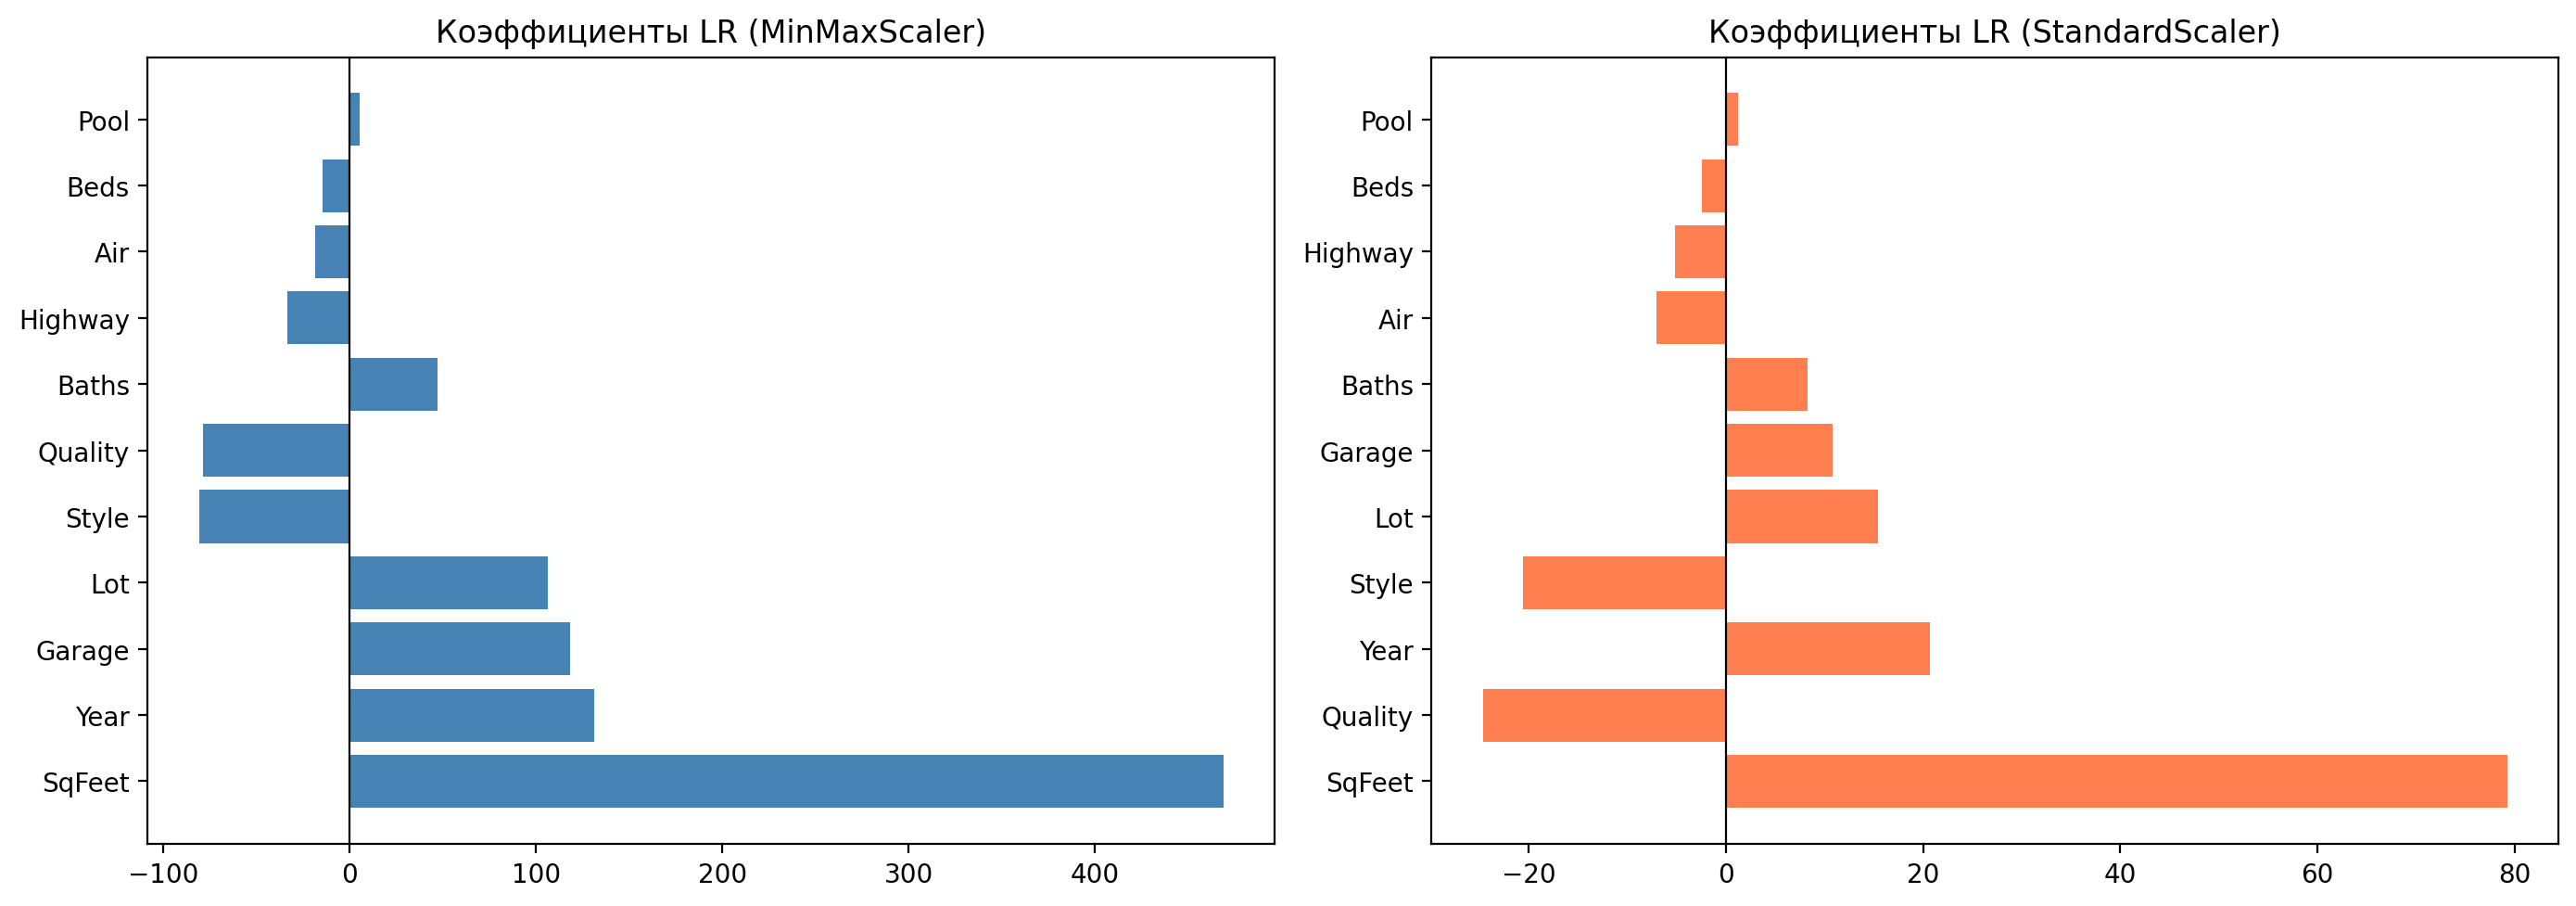


Ранжирование признаков по |коэффициенту|:
Признак         |  MinMax ранг |   Std ранг
---------------------------------------------
SqFeet          |            1 |          1
Beds            |           10 |         10
Baths           |            7 |          7
Air             |            9 |          8
Garage          |            3 |          6
Pool            |           11 |         11
Year            |            2 |          3
Quality         |            6 |          2
Style           |            5 |          4
Lot             |            4 |          5
Highway         |            8 |          9


In [17]:
lr_mm_m = LinearRegression().fit(X_train_mm, y_train)
lr_std_m = LinearRegression().fit(X_train_std, y_train)
fn = list(X_train.columns)
c_mm = lr_mm_m.coef_; c_std = lr_std_m.coef_
i_mm = np.argsort(np.abs(c_mm))[::-1]
i_std = np.argsort(np.abs(c_std))[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh([fn[i] for i in i_mm], c_mm[i_mm], color='steelblue')
axes[0].set_title('Коэффициенты LR (MinMaxScaler)'); axes[0].axvline(0, color='k', lw=0.8)
axes[1].barh([fn[i] for i in i_std], c_std[i_std], color='coral')
axes[1].set_title('Коэффициенты LR (StandardScaler)'); axes[1].axvline(0, color='k', lw=0.8)
plt.tight_layout(); plt.show()

print('\nРанжирование признаков по |коэффициенту|:')
print(f"{'Признак':15s} | {'MinMax ранг':>12} | {'Std ранг':>10}")
print('-'*45)
r_mm = {fn[i]: r+1 for r,i in enumerate(i_mm)}
r_std = {fn[i]: r+1 for r,i in enumerate(i_std)}
for f in fn:
    print(f'{f:15s} | {r_mm[f]:>12} | {r_std[f]:>10}')

### Выводы по Заданию 1.1

**Качество предсказаний** одинаково для обоих скейлеров у LinearRegression.

**Важность признаков (коэффициенты):**
- MinMaxScaler: коэффициент = изменение предсказания при изменении признака от min до max.
- StandardScaler: коэффициент = изменение предсказания при изменении признака на 1 std.

**Порядок важности** может отличаться, так как MinMax чувствителен к выбросам.

## Задание 2. 1 балл

Выберите 1 признак для анализа (можно категориальный, с не менее чем 5 уровнями, или дискретизируйте непрерывный).

Используйте линейную регрессию и бустинг после применения MinMaxScaler. Что будет с моделями, если признаки выйдут из диапазона?

Постройте графики ICE и PDP для интерпретации исходных данных, а также искусственно добавив несколько выбросов, выходящих за оригинальные интервалы.

Задание 2.1 (*) 1 балл: проанализируйте также еще один признак

In [18]:
feature_for_analysis = 'SqFeet'
feature_idx = list(X_train.columns).index(feature_for_analysis)
print(f'Признак: {feature_for_analysis}')
print(f'Мин: {X_train[feature_for_analysis].min():.3f}, Макс: {X_train[feature_for_analysis].max():.3f}')
print(f'Уникальных значений: {X_train[feature_for_analysis].nunique()}')
bins = pd.cut(X_train[feature_for_analysis], bins=5)
print('\nРаспределение по 5 бинам:')
print(bins.value_counts().sort_index())

Признак: SqFeet
Мин: 0.980, Макс: 5.032
Уникальных значений: 343

Распределение по 5 бинам:
SqFeet
(0.976, 1.79]     130
(1.79, 2.601]     173
(2.601, 3.411]     85
(3.411, 4.222]     23
(4.222, 5.032]      5
Name: count, dtype: int64


In [19]:
scaler_mm2 = MinMaxScaler()
X_train_mm2 = scaler_mm2.fit_transform(X_train)
X_test_mm2 = scaler_mm2.transform(X_test)
lr_mm2 = LinearRegression().fit(X_train_mm2, y_train)
gbr_mm2 = GradientBoostingRegressor(max_depth=5, n_estimators=100, random_state=42)
gbr_mm2.fit(X_train_mm2, y_train)
print('LR R2:', r2_score(y_test, lr_mm2.predict(X_test_mm2)))
print('GBR R2:', r2_score(y_test, gbr_mm2.predict(X_test_mm2)))

LR R2: 0.7691270514260318
GBR R2: 0.7703499335434747


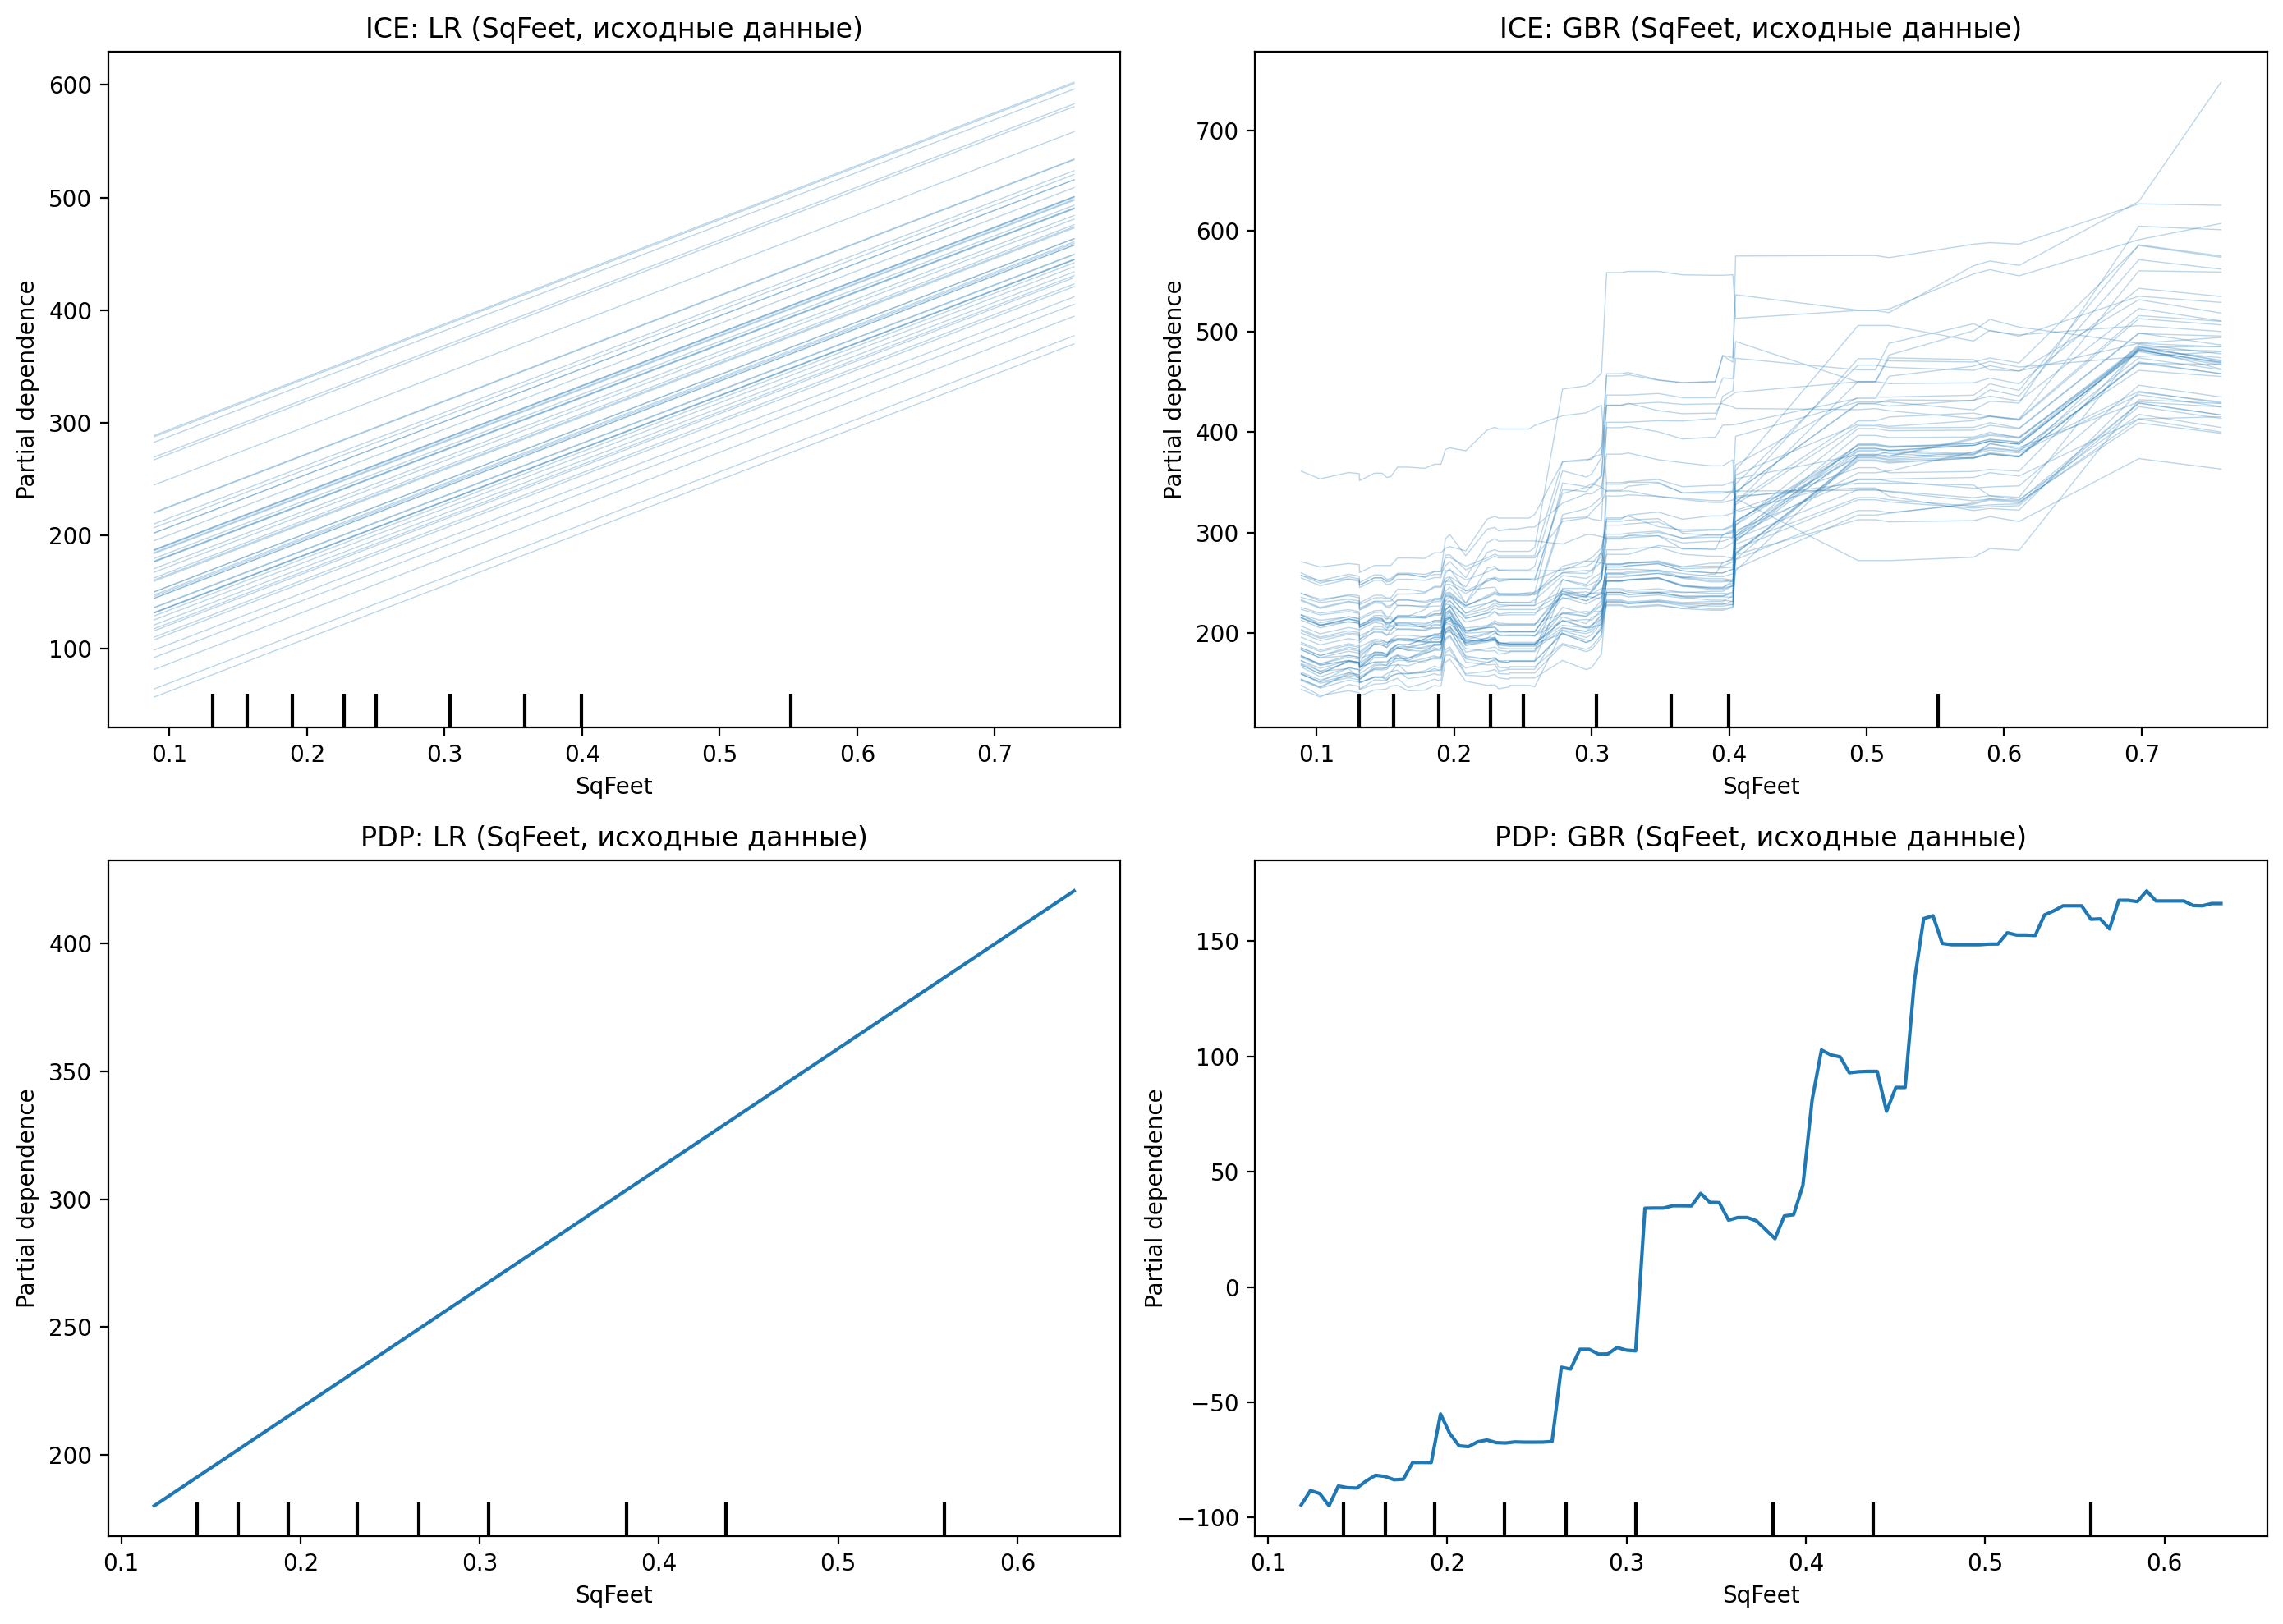

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
rng = np.random.RandomState(42)
s_idx = rng.choice(len(X_test_mm2), size=50, replace=False)
X_te_s = X_test_mm2[s_idx]
fn = list(X_train.columns)

PartialDependenceDisplay.from_estimator(lr_mm2, X_te_s, [feature_idx], kind='individual', ax=axes[0,0], feature_names=fn)
axes[0,0].set_title(f'ICE: LR ({feature_for_analysis}, исходные данные)')
PartialDependenceDisplay.from_estimator(gbr_mm2, X_te_s, [feature_idx], kind='individual', ax=axes[0,1], feature_names=fn)
axes[0,1].set_title(f'ICE: GBR ({feature_for_analysis}, исходные данные)')
PartialDependenceDisplay.from_estimator(lr_mm2, X_train_mm2, [feature_idx], kind='average', ax=axes[1,0], feature_names=fn)
axes[1,0].set_title(f'PDP: LR ({feature_for_analysis}, исходные данные)')
PartialDependenceDisplay.from_estimator(gbr_mm2, X_train_mm2, [feature_idx], kind='average', ax=axes[1,1], feature_names=fn)
axes[1,1].set_title(f'PDP: GBR ({feature_for_analysis}, исходные данные)')
plt.tight_layout(); plt.show()

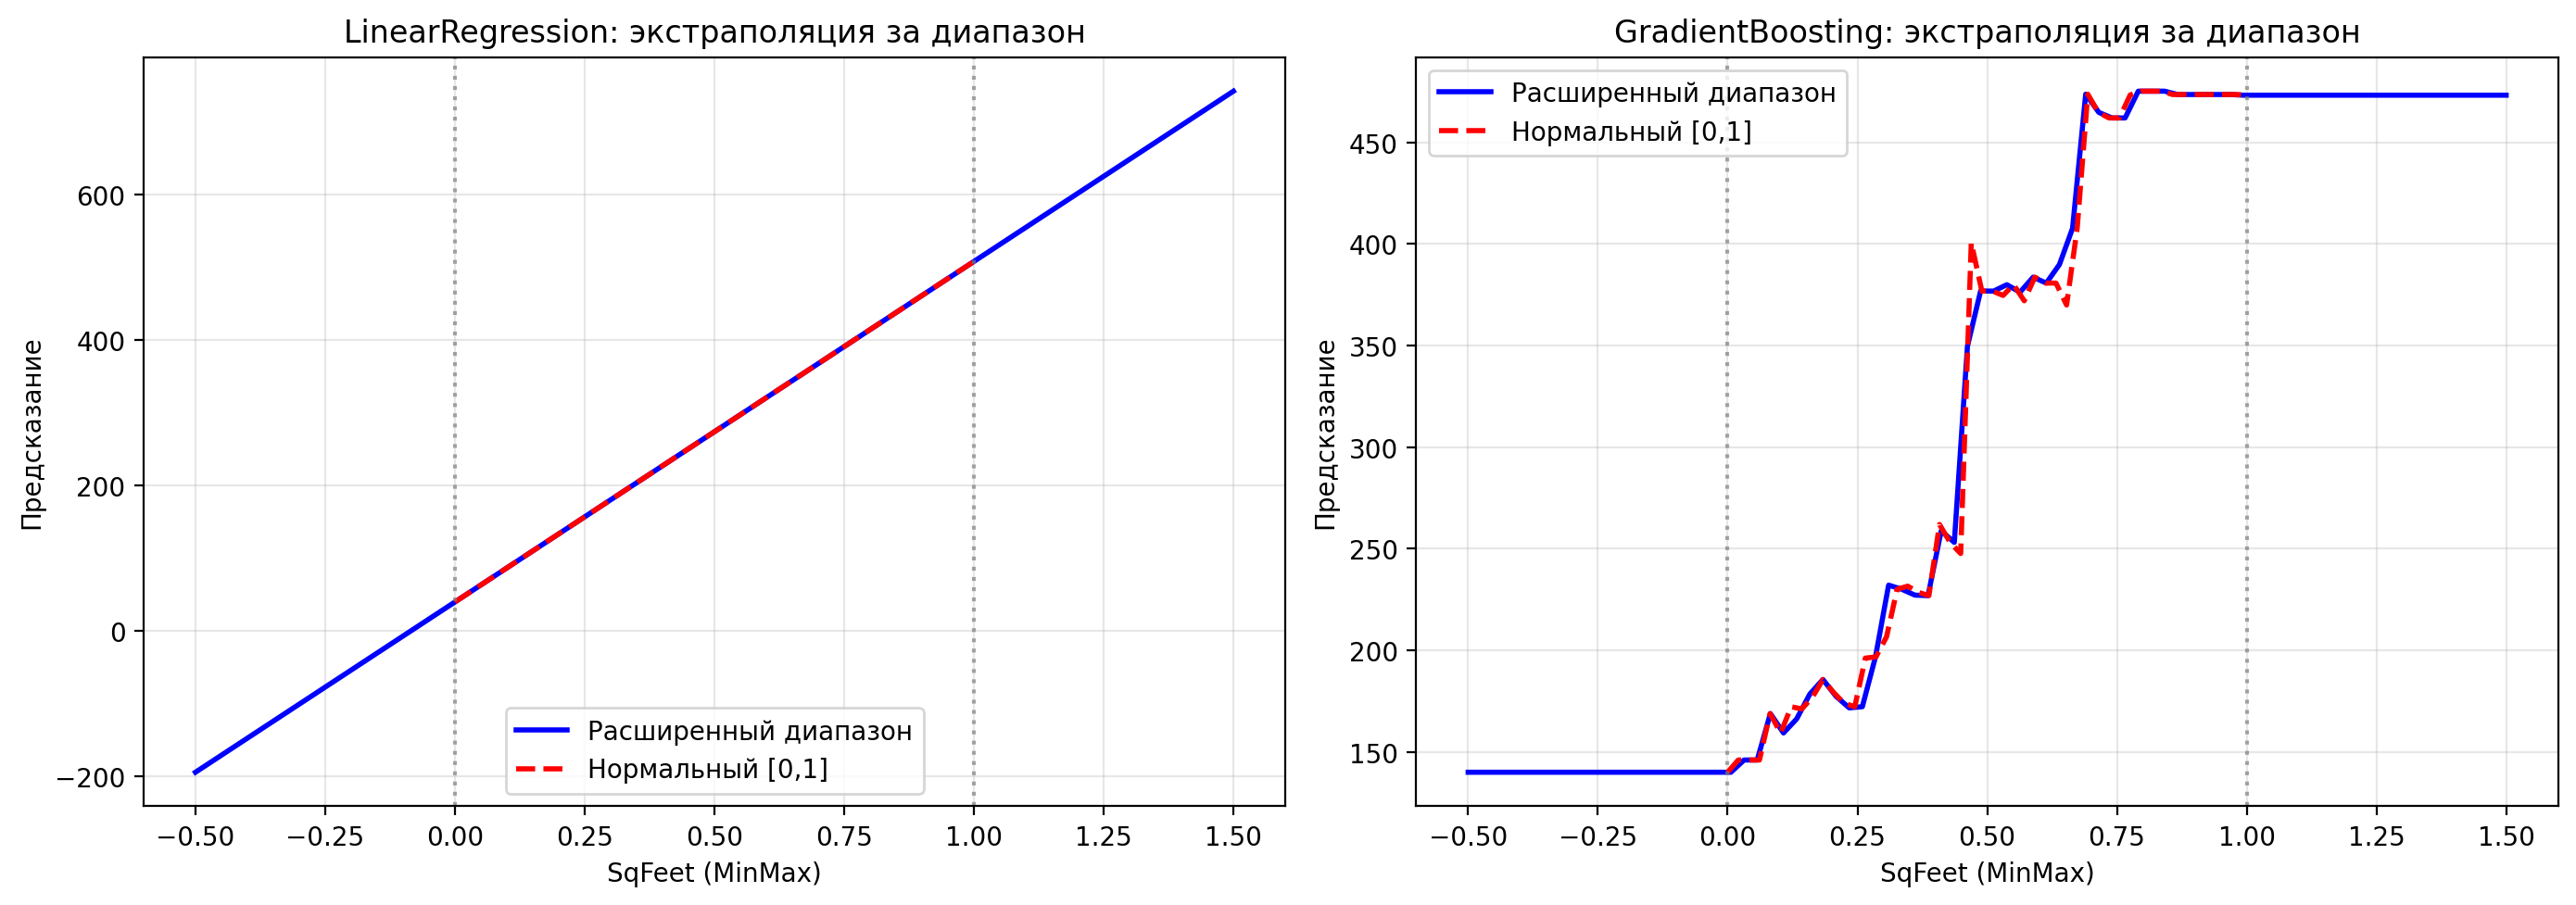

LR: экстраполирует линейно за пределы обучающего диапазона.
GBR: замораживает предсказание на граничных значениях.


In [21]:
grid_n = np.linspace(0, 1, 50)
grid_e = np.linspace(-0.5, 1.5, 80)
base = X_test_mm2[0:1].copy()
lr_n, gbr_n, lr_e, gbr_e = [], [], [], []
for v in grid_n:
    s = base.copy(); s[0, feature_idx] = v
    lr_n.append(lr_mm2.predict(s)[0]); gbr_n.append(gbr_mm2.predict(s)[0])
for v in grid_e:
    s = base.copy(); s[0, feature_idx] = v
    lr_e.append(lr_mm2.predict(s)[0]); gbr_e.append(gbr_mm2.predict(s)[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pn, pe, title in [(axes[0],lr_n,lr_e,'LinearRegression'),(axes[1],gbr_n,gbr_e,'GradientBoosting')]:
    ax.plot(grid_e, pe, 'b-', lw=2, label='Расширенный диапазон')
    ax.plot(grid_n, pn, 'r--', lw=2, label='Нормальный [0,1]')
    ax.axvline(0, color='gray', ls=':', alpha=0.7); ax.axvline(1, color='gray', ls=':', alpha=0.7)
    ax.set_xlabel(f'{feature_for_analysis} (MinMax)'); ax.set_ylabel('Предсказание')
    ax.set_title(f'{title}: экстраполяция за диапазон'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print('LR: экстраполирует линейно за пределы обучающего диапазона.')
print('GBR: замораживает предсказание на граничных значениях.')

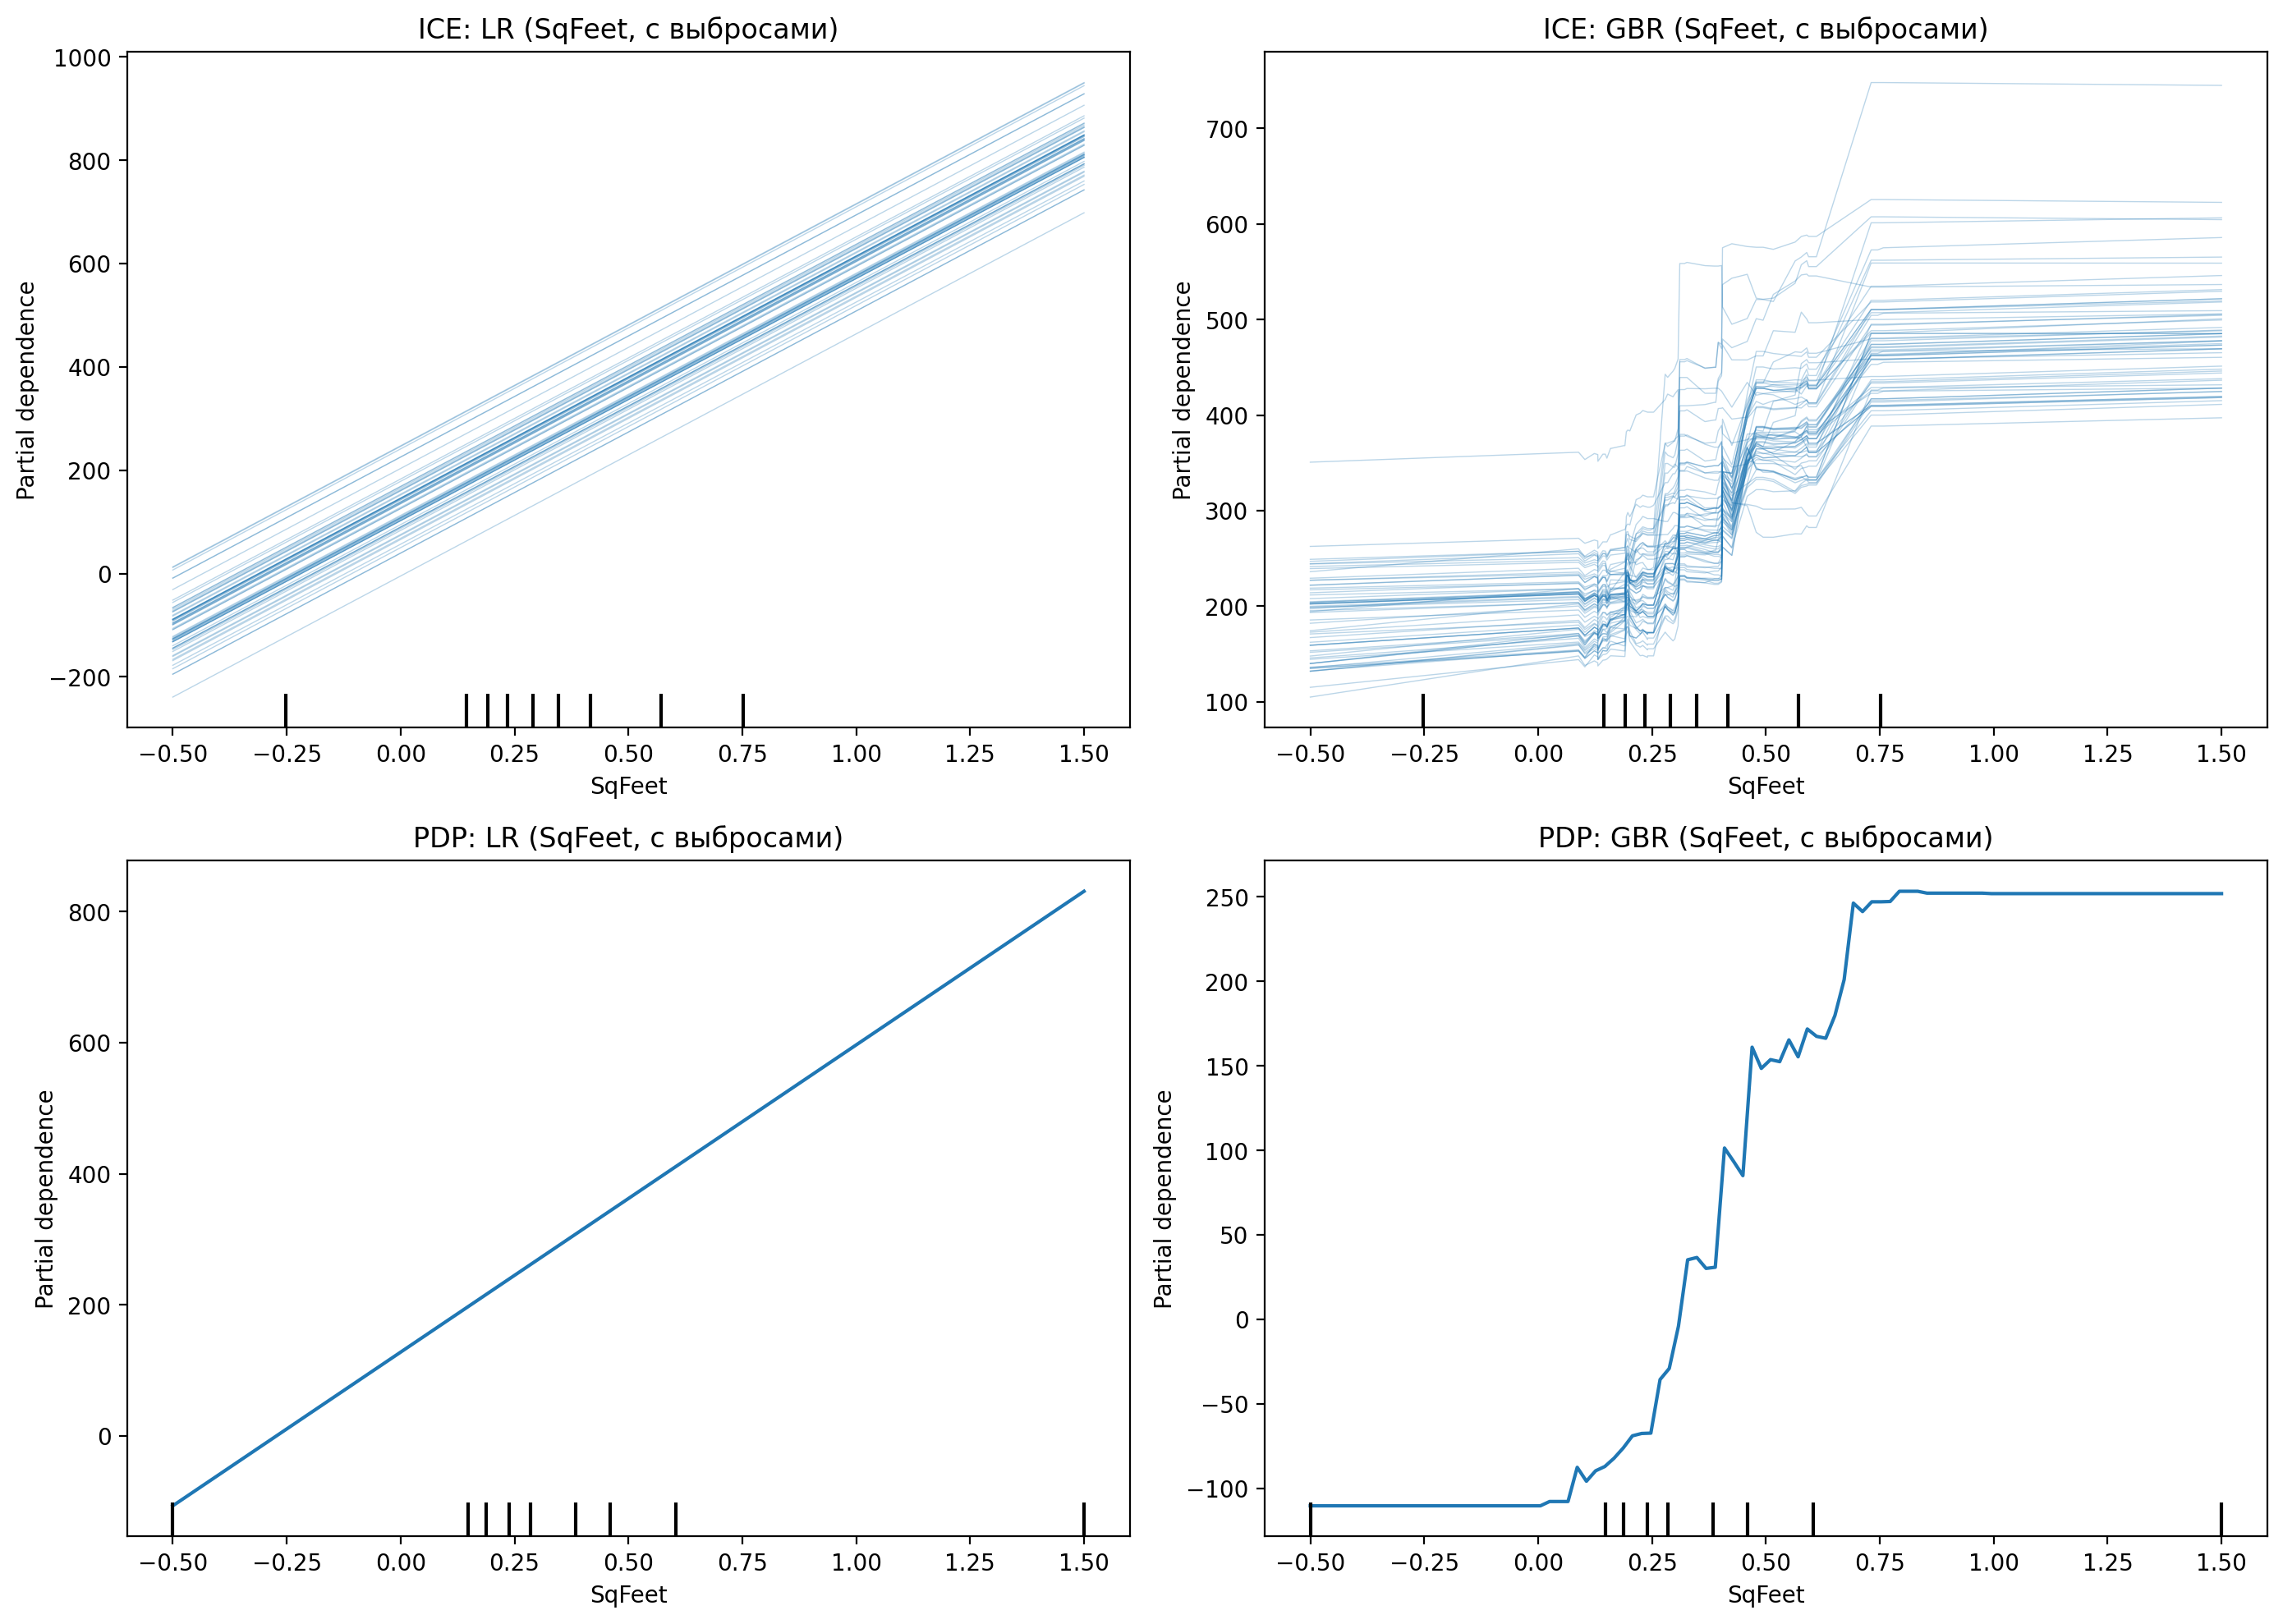

In [22]:
n_out = 15
X_ol = X_test_mm2[:n_out].copy(); X_oh = X_test_mm2[:n_out].copy()
X_ol[:, feature_idx] = -0.5; X_oh[:, feature_idx] = 1.5
X_wo = np.vstack([X_test_mm2, X_ol, X_oh])
rng2 = np.random.RandomState(42)
si = rng2.choice(len(X_wo), size=60, replace=False)
X_wo_s = X_wo[si]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fn = list(X_train.columns)
PartialDependenceDisplay.from_estimator(lr_mm2, X_wo_s, [feature_idx], kind='individual', ax=axes[0,0], feature_names=fn)
axes[0,0].set_title(f'ICE: LR ({feature_for_analysis}, с выбросами)')
PartialDependenceDisplay.from_estimator(gbr_mm2, X_wo_s, [feature_idx], kind='individual', ax=axes[0,1], feature_names=fn)
axes[0,1].set_title(f'ICE: GBR ({feature_for_analysis}, с выбросами)')
PartialDependenceDisplay.from_estimator(lr_mm2, X_wo, [feature_idx], kind='average', ax=axes[1,0], feature_names=fn)
axes[1,0].set_title(f'PDP: LR ({feature_for_analysis}, с выбросами)')
PartialDependenceDisplay.from_estimator(gbr_mm2, X_wo, [feature_idx], kind='average', ax=axes[1,1], feature_names=fn)
axes[1,1].set_title(f'PDP: GBR ({feature_for_analysis}, с выбросами)')
plt.tight_layout(); plt.show()

### Задание 2.1 (*): Второй признак — Year (год постройки)

In [23]:
feature2 = 'Year'
feature2_idx = list(X_train.columns).index(feature2)
print(f'Признак: {feature2}')
print(f'Мин: {X_train[feature2].min()}, Макс: {X_train[feature2].max()}')
print(f'Уникальных значений: {X_train[feature2].nunique()}')
bins2 = pd.cut(X_train[feature2], bins=5)
print('\nРаспределение по 5 бинам:')
print(bins2.value_counts().sort_index())

Признак: Year
Мин: 1885, Макс: 1998
Уникальных значений: 71

Распределение по 5 бинам:
Year
(1884.887, 1907.6]      2
(1907.6, 1930.2]       14
(1930.2, 1952.8]       57
(1952.8, 1975.4]      189
(1975.4, 1998.0]      154
Name: count, dtype: int64


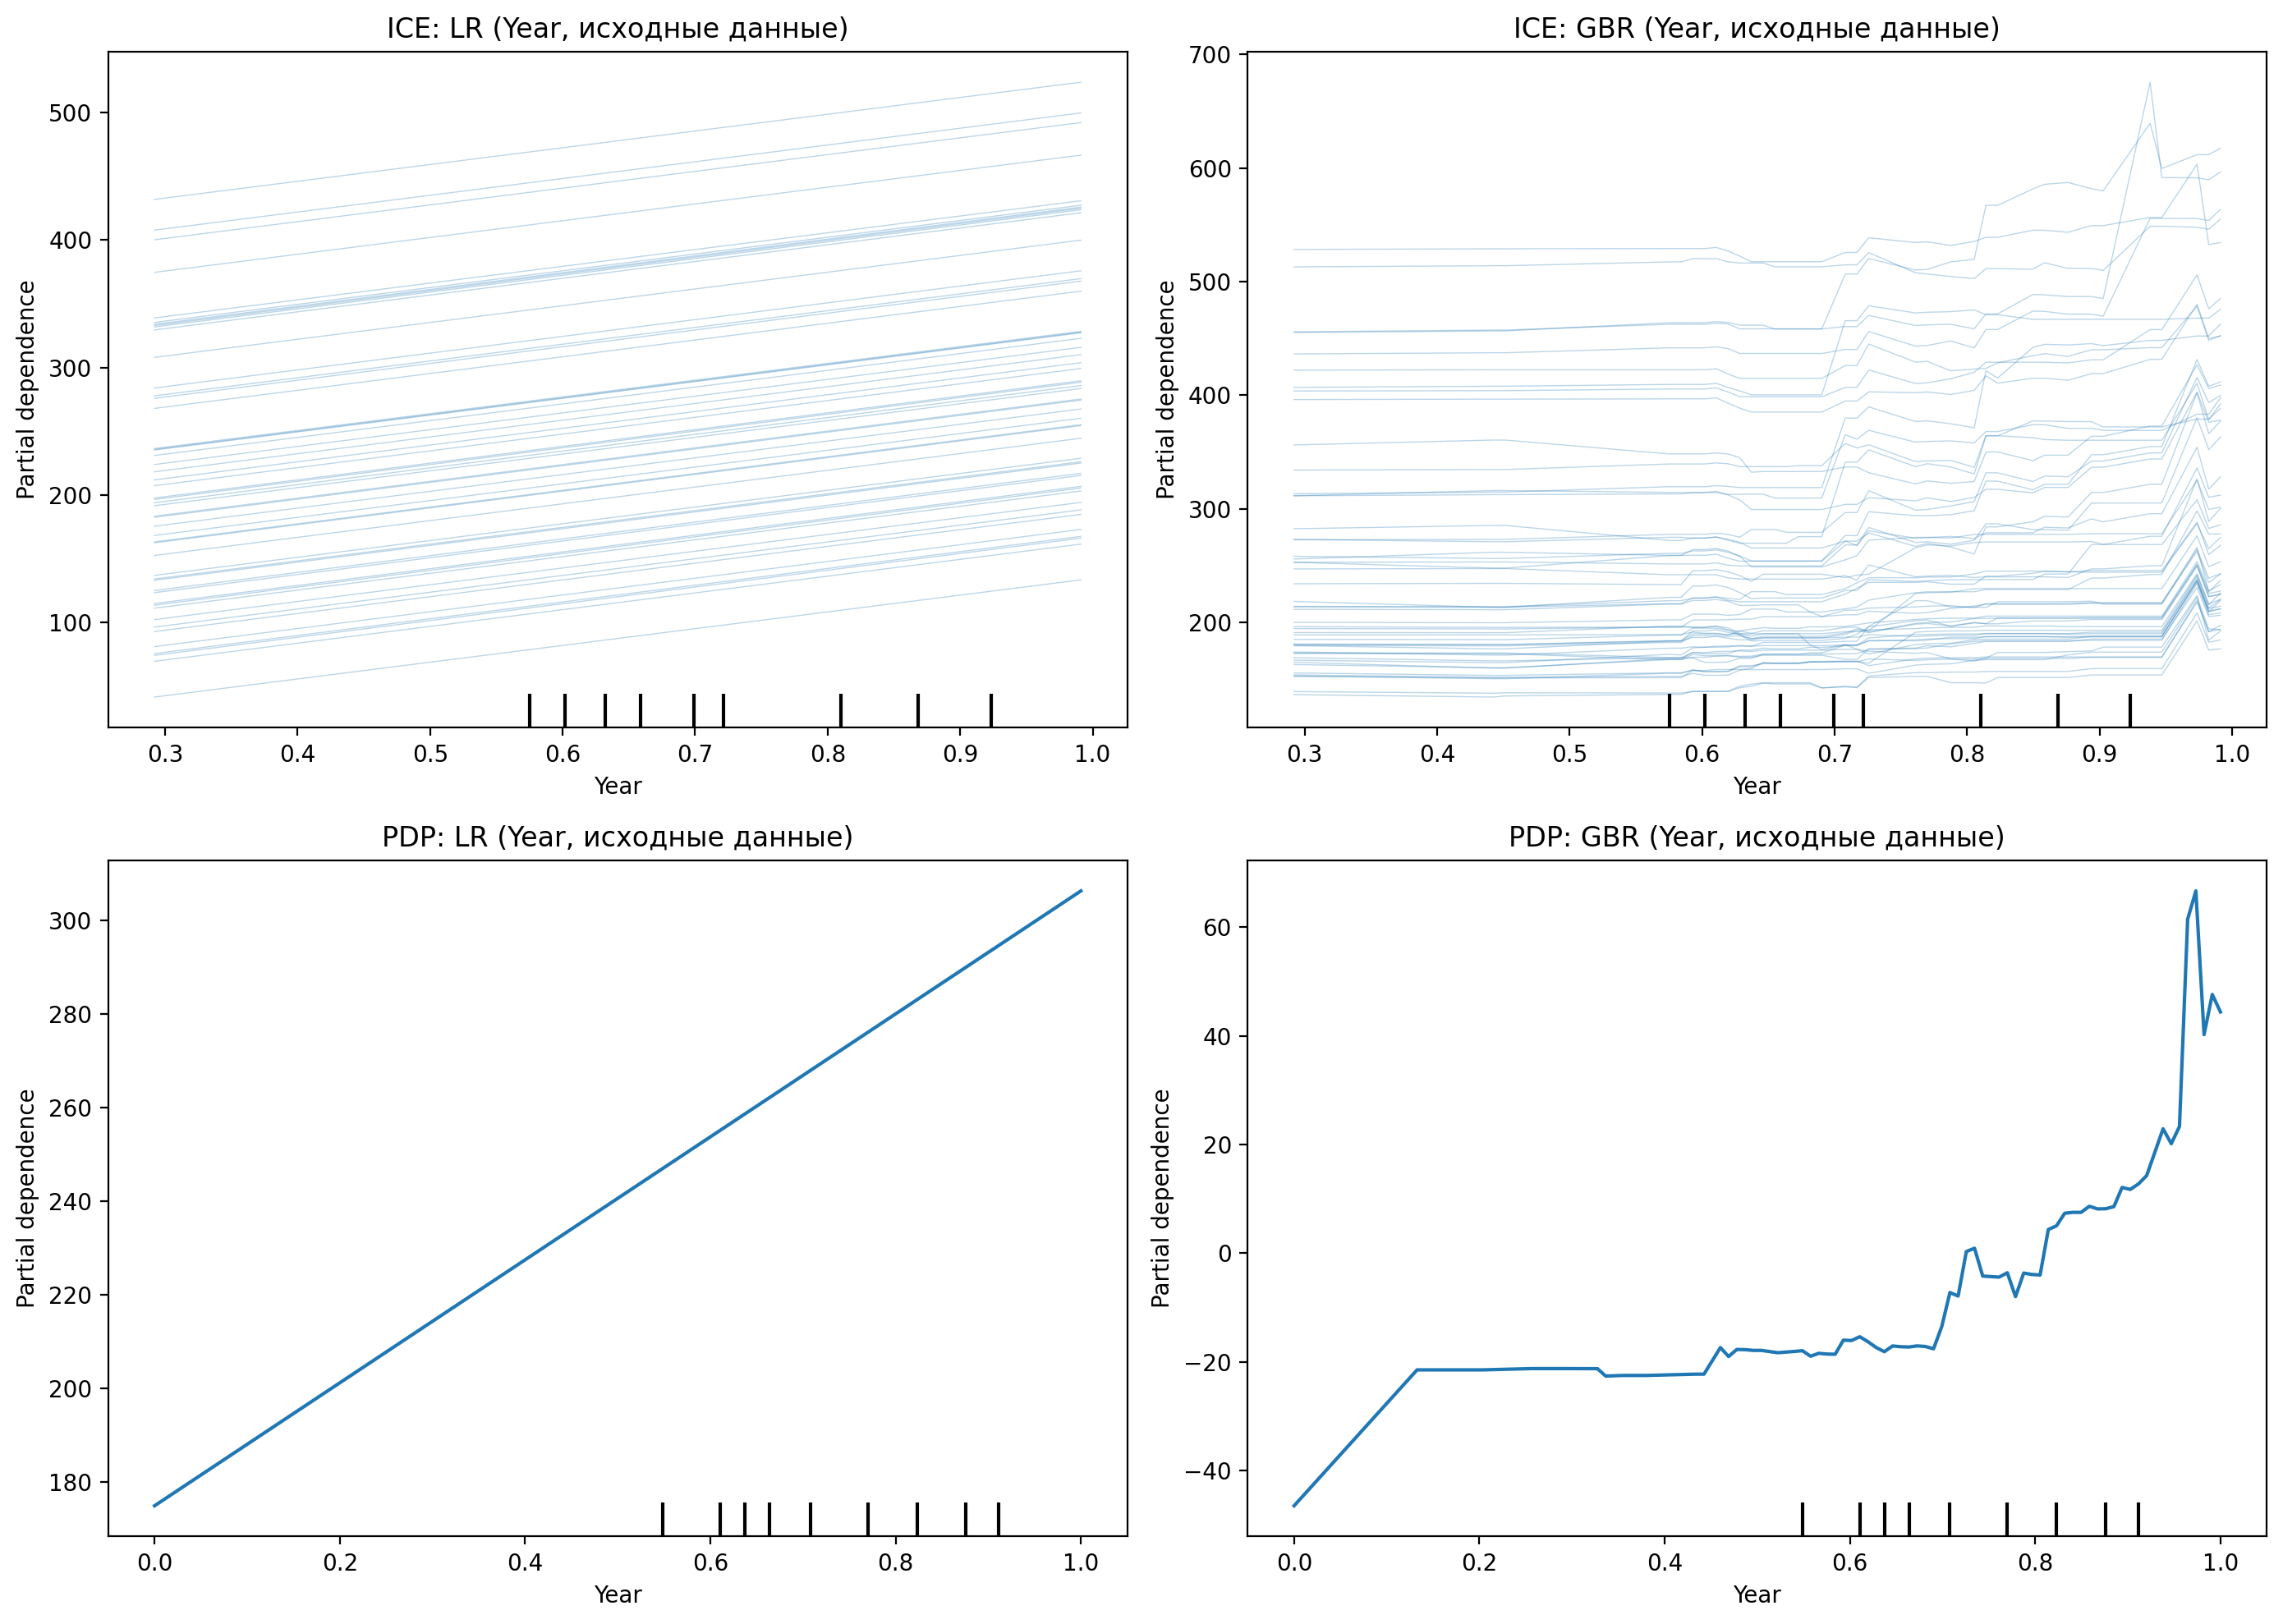

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fn = list(X_train.columns)
PartialDependenceDisplay.from_estimator(lr_mm2, X_te_s, [feature2_idx], kind='individual', ax=axes[0,0], feature_names=fn)
axes[0,0].set_title(f'ICE: LR ({feature2}, исходные данные)')
PartialDependenceDisplay.from_estimator(gbr_mm2, X_te_s, [feature2_idx], kind='individual', ax=axes[0,1], feature_names=fn)
axes[0,1].set_title(f'ICE: GBR ({feature2}, исходные данные)')
PartialDependenceDisplay.from_estimator(lr_mm2, X_train_mm2, [feature2_idx], kind='average', ax=axes[1,0], feature_names=fn)
axes[1,0].set_title(f'PDP: LR ({feature2}, исходные данные)')
PartialDependenceDisplay.from_estimator(gbr_mm2, X_train_mm2, [feature2_idx], kind='average', ax=axes[1,1], feature_names=fn)
axes[1,1].set_title(f'PDP: GBR ({feature2}, исходные данные)')
plt.tight_layout(); plt.show()

### Выводы по Заданию 2

**ICE:** У LR все кривые параллельны (нет взаимодействий). У GBR кривые имеют разный наклон — модель улавливает нелинейности и взаимодействия.

**PDP:** LR: строго линейная зависимость. GBR: нелинейная — рост цены замедляется при очень больших площадях.

**Поведение при выбросах:**
- **LR** экстраполирует линейно — предсказания могут уйти в нереалистичные значения.
- **GBR** замораживает предсказание на граничных значениях — за пределами обучающего диапазона предсказание константно.

**Year:** Год постройки показывает монотонный рост цены у LR, а у GBR — нелинейный эффект с ускорением роста для новых домов.

## Задание 3. 1 балл

Выберите 20 объектов из тестовой выборки.

Для каждого объекта из выбранного набора построим траекторию изменения предсказания модели при постепенном изменении значения признака от его текущего значения к базовому значению (медиана или среднее по обучающей выборке).

**Алгоритм:**

1. Выбрать объект $x_i$ из тестовой выборки

2. Для интересующего признака $j$:

   - Текущее значение: $x_{i,j}$

   - Базовое значение: $x_{base,j}$ (медиана или среднее по обучающей выборке)

3. Построить линейную интерполяцию между $x_{i,j}$ и $x_{base,j}$ с $n$ шагами

4. Для каждого шага интерполяции:

   - Заменить значение признака $j$ в объекте $x_i$ на значение из интерполяции

   - Вычислить предсказание модели для модифицированного объекта

5. Построить график траектории

Задание 3.1 (*) 1 балл: проанализируйте также еще один признак
### ваш код

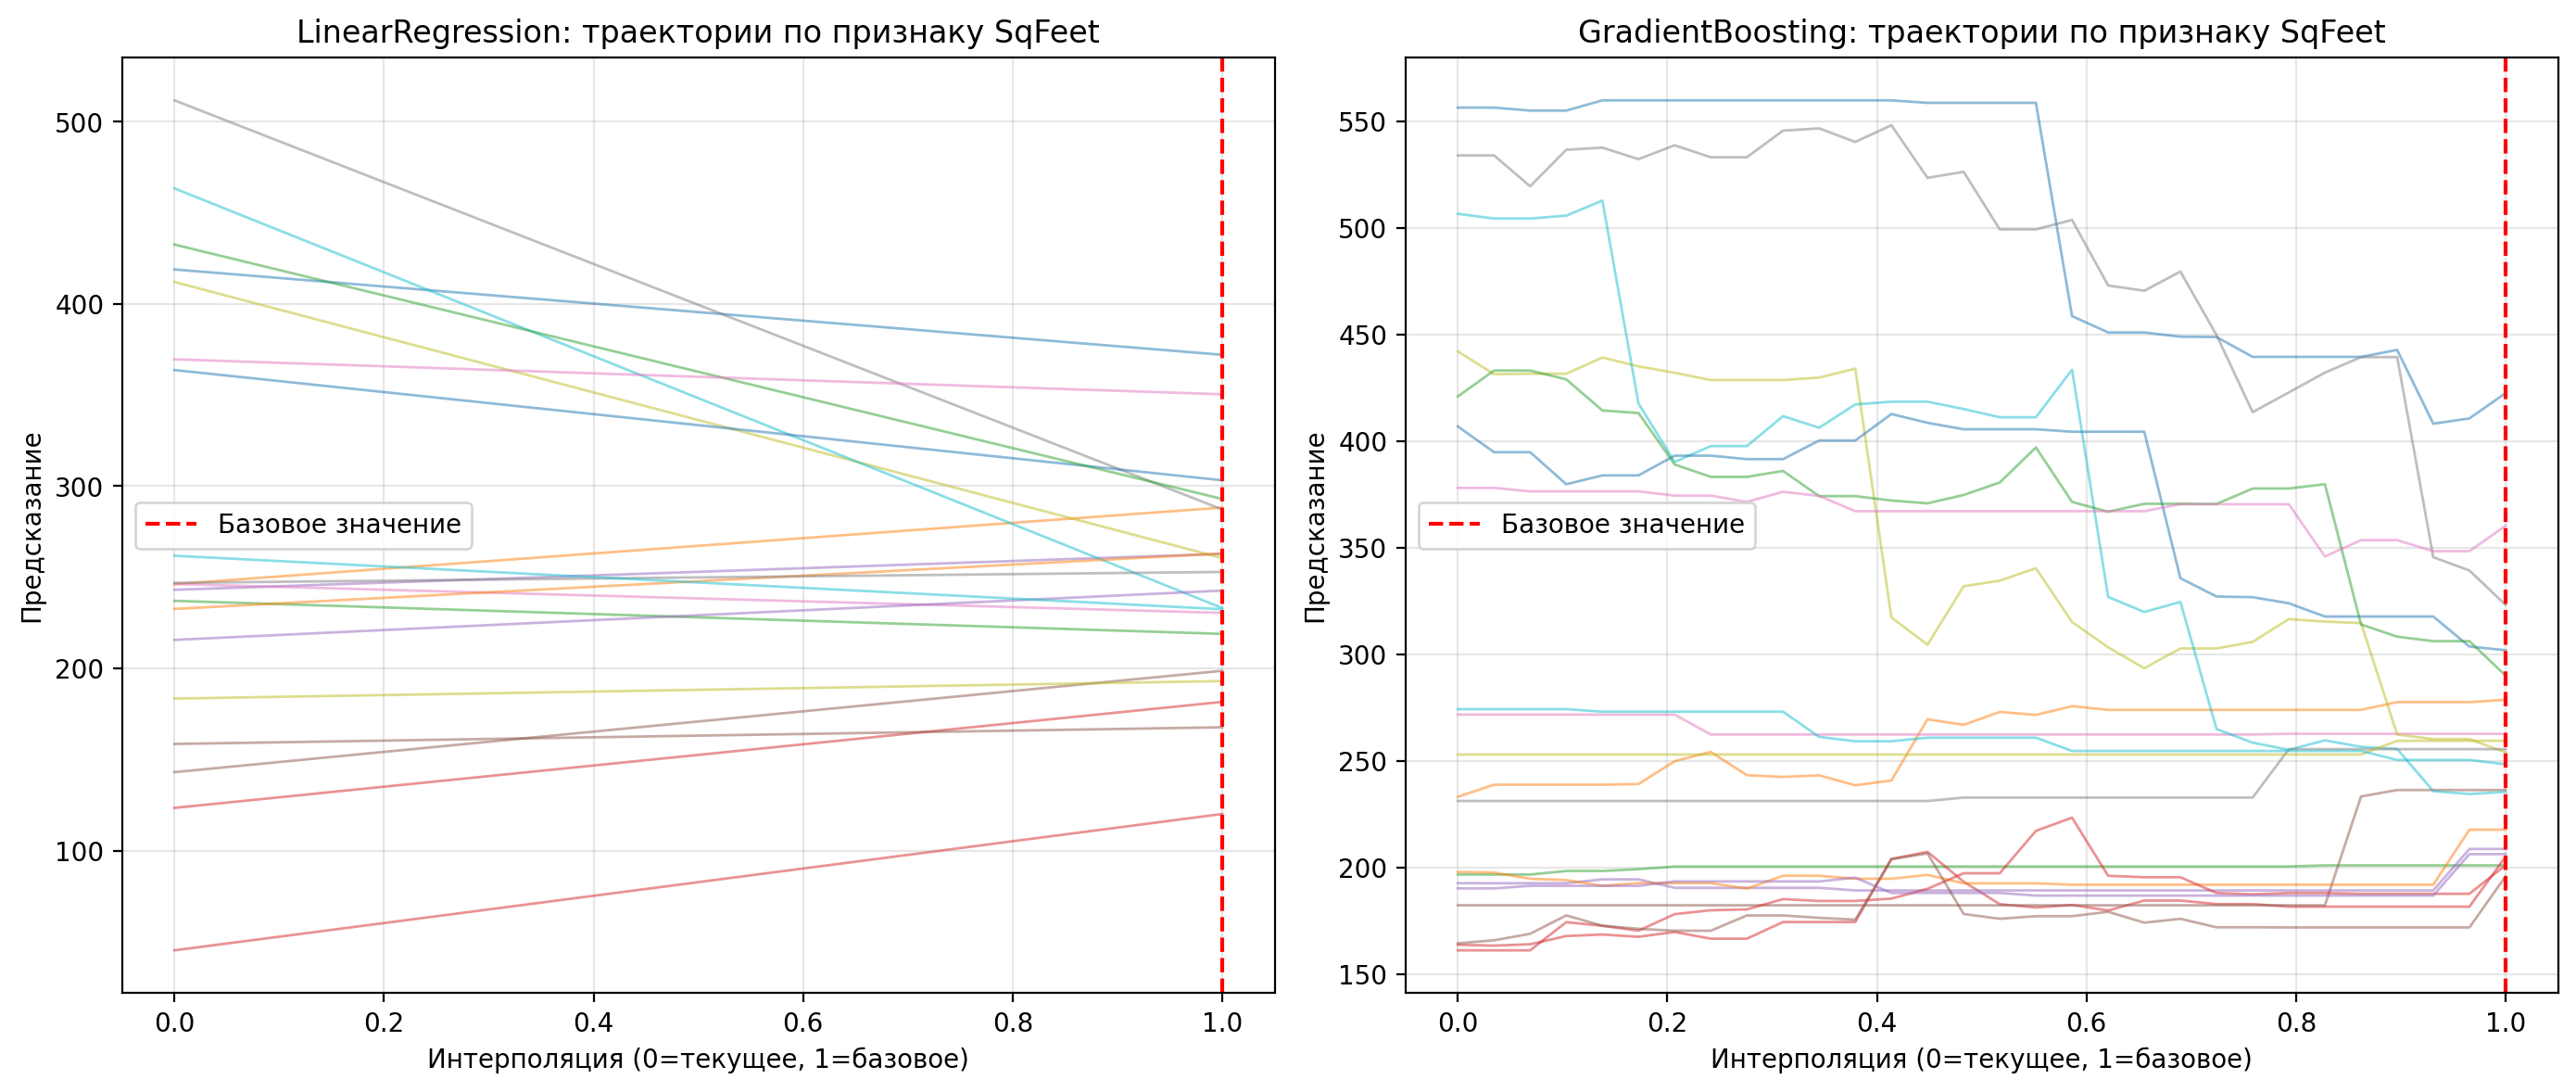

In [26]:
# Выбираем 20 объектов из тестовой выборки
rng3 = np.random.RandomState(0)
obj_idx = rng3.choice(len(X_test_mm2), size=20, replace=False)
X_20 = X_test_mm2[obj_idx]

# Базовое значение — медиана по обучающей выборке (в пространстве MinMax)
base_vals = np.median(X_train_mm2, axis=0)

n_steps = 30

def plot_trajectories(model, X_objects, base_vals, feat_idx, feat_name, model_name, ax):
    for i, xi in enumerate(X_objects):
        x_start = xi[feat_idx]
        x_base = base_vals[feat_idx]
        interp = np.linspace(x_start, x_base, n_steps)
        preds = []
        for v in interp:
            xi_mod = xi.copy()
            xi_mod[feat_idx] = v
            preds.append(model.predict(xi_mod.reshape(1,-1))[0])
        ax.plot(np.linspace(0, 1, n_steps), preds, alpha=0.5, lw=1)
    ax.axvline(1.0, color='red', ls='--', lw=1.5, label='Базовое значение')
    ax.set_xlabel('Интерполяция (0=текущее, 1=базовое)')
    ax.set_ylabel('Предсказание')
    ax.set_title(f'{model_name}: траектории по признаку {feat_name}')
    ax.legend(); ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_trajectories(lr_mm2, X_20, base_vals, feature_idx, feature_for_analysis, 'LinearRegression', axes[0])
plot_trajectories(gbr_mm2, X_20, base_vals, feature_idx, feature_for_analysis, 'GradientBoosting', axes[1])
plt.tight_layout(); plt.show()

### Задание 3.1 (*): Второй признак — Year

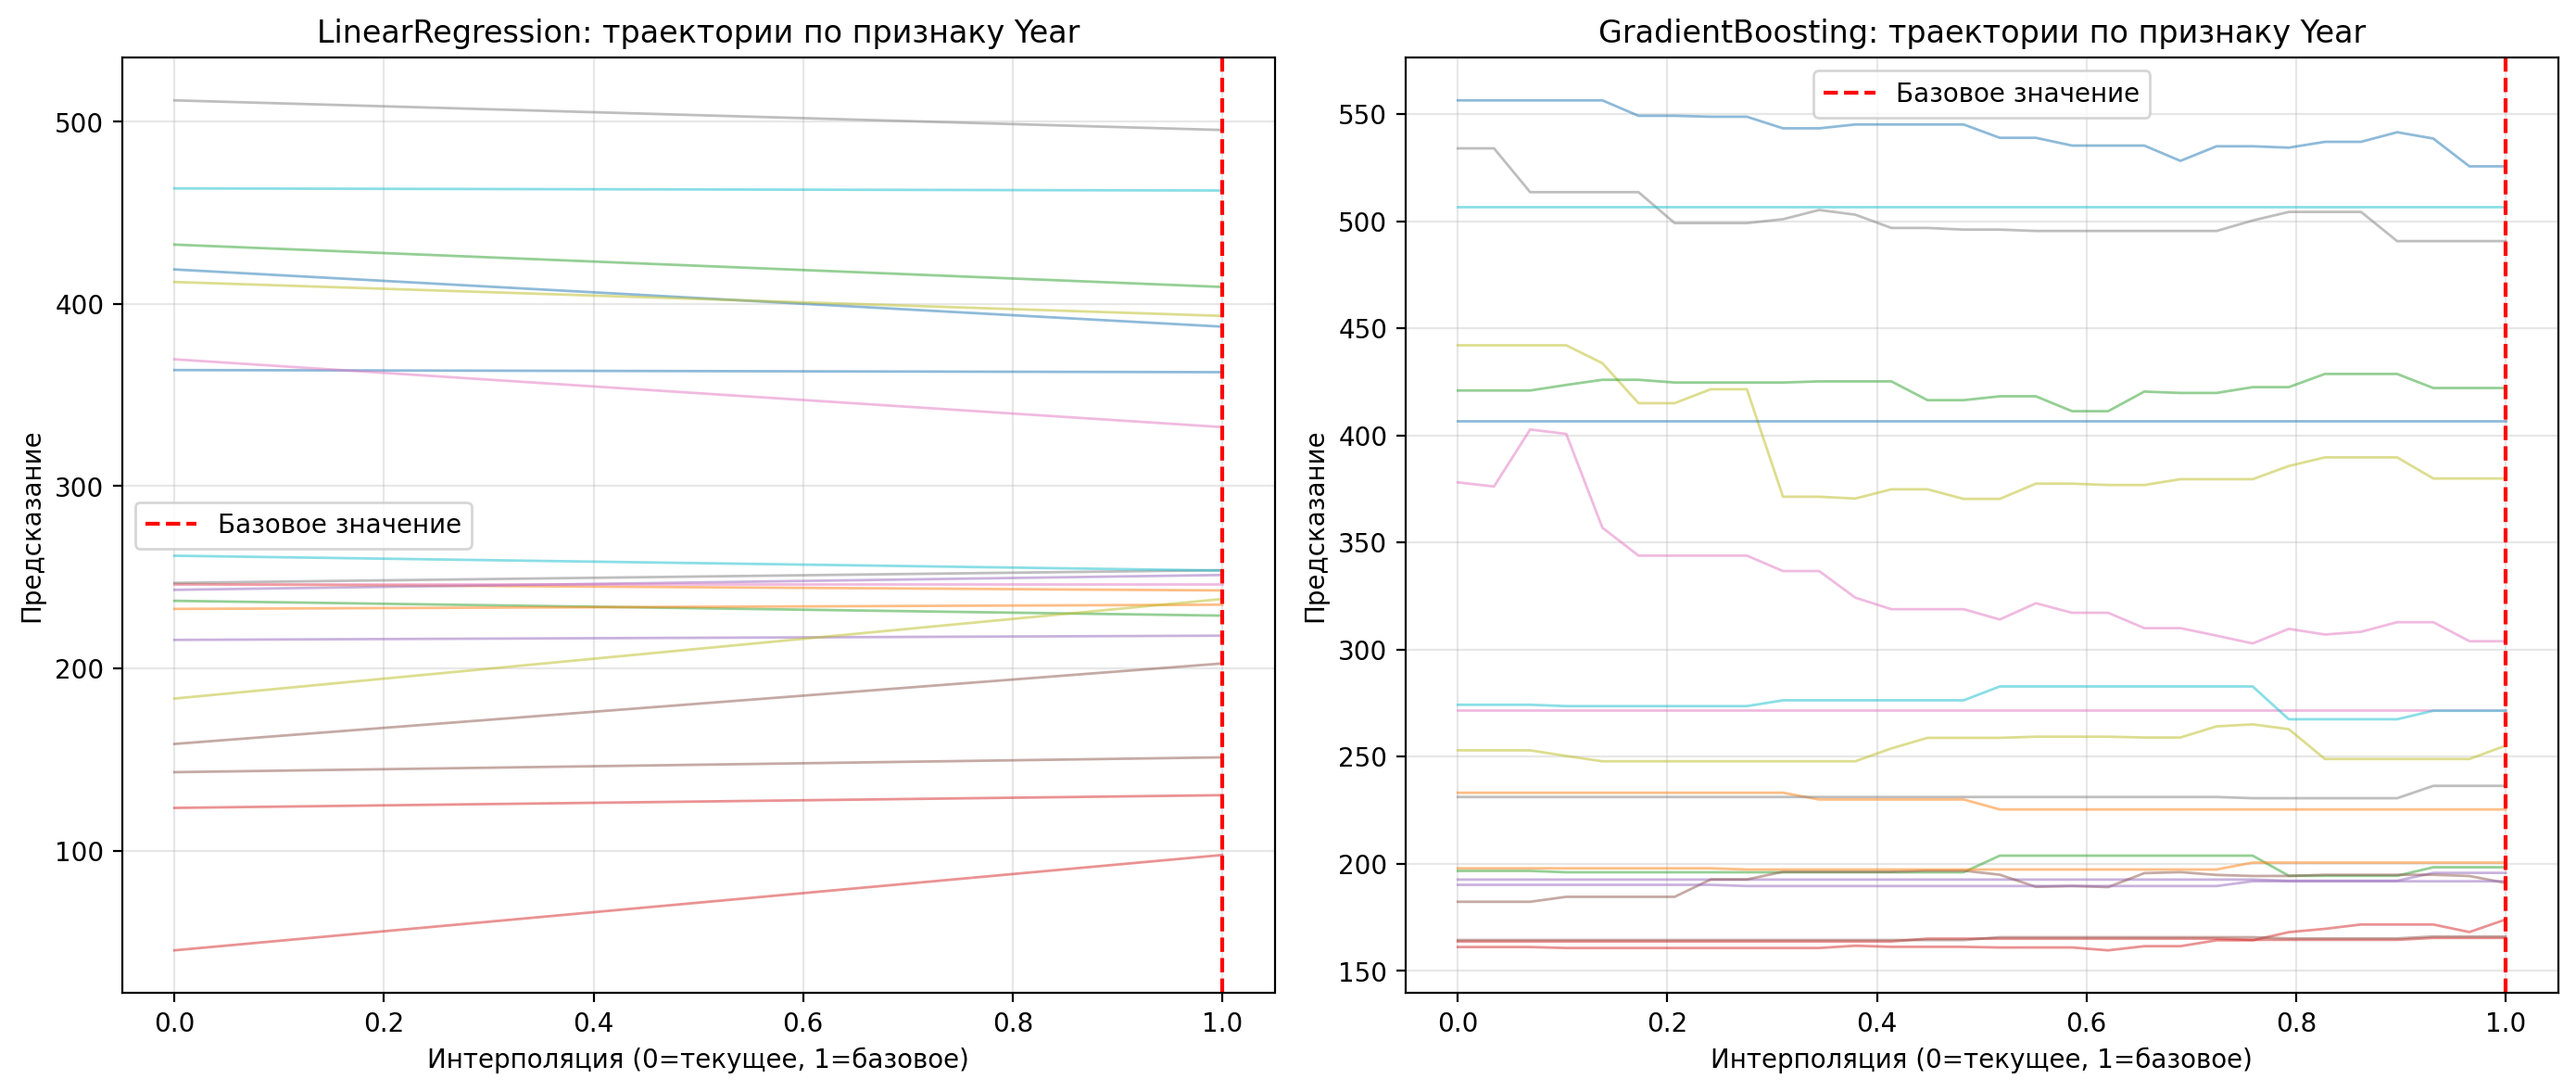

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_trajectories(lr_mm2, X_20, base_vals, feature2_idx, feature2, 'LinearRegression', axes[0])
plot_trajectories(gbr_mm2, X_20, base_vals, feature2_idx, feature2, 'GradientBoosting', axes[1])
plt.tight_layout(); plt.show()

### Выводы по Заданию 3

**LinearRegression:** Все траектории монотонны и параллельны — линейная зависимость. Изменение признака к базовому значению приводит к предсказуемому линейному изменению предсказания.

**GradientBoosting:** Траектории нелинейны и разнообразны — разные объекты реагируют по-разному на изменение признака. Это отражает взаимодействия признаков в модели.

**Интерпретация:** Если траектория идёт вверх при движении к базовому значению, значит текущее значение признака снижает предсказание относительно базового. Крутизна траектории показывает чувствительность предсказания к данному признаку.

## Задание 4 (1 балл). ALE

Постройте ALE по обеим моделям, используя pyALE. Подберите размер сетки так, чтобы получить доверительные интервалы. Проанализируйте полученный график. Каковы получились доверительные интервалы? Почему они различны для моделей?

P.s. Сетку значений стройте для исходного признака.
### ваш код

In [28]:
from PyALE import ale

# Для pyALE нужен DataFrame с исходными (не нормализованными) значениями
# и модель, принимающая такие же данные
# Обучим модели на исходных данных (без нормализации) для ALE
lr_raw_ale = LinearRegression().fit(X_train_raw, y_train)
gbr_raw_ale = GradientBoostingRegressor(max_depth=5, n_estimators=100, random_state=42)
gbr_raw_ale.fit(X_train_raw, y_train)

X_test_df = pd.DataFrame(X_test_raw, columns=list(X_train.columns))
X_train_df = pd.DataFrame(X_train_raw, columns=list(X_train.columns))

print('LR R2 (raw):', r2_score(y_test, lr_raw_ale.predict(X_test_raw)))
print('GBR R2 (raw):', r2_score(y_test, gbr_raw_ale.predict(X_test_raw)))

LR R2 (raw): 0.769127051426032
GBR R2 (raw): 0.770323927018141


PyALE._ALE_generic:INFO: Continuous feature detected.


ALE для LinearRegression, признак SqFeet:


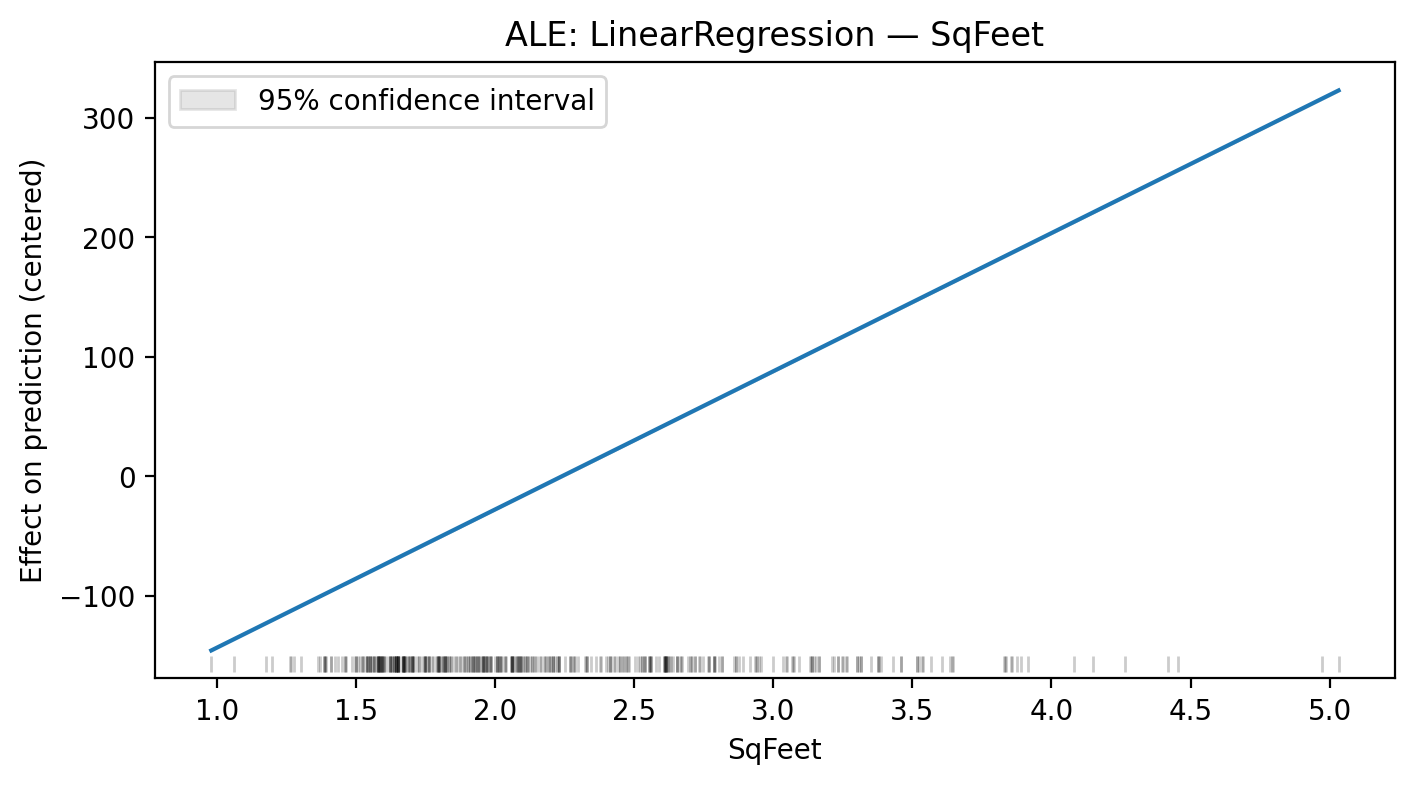

In [29]:
# ALE для LinearRegression — признак SqFeet
# grid_size >= 5 для получения доверительных интервалов
print('ALE для LinearRegression, признак SqFeet:')
ale_lr = ale(
    X=X_train_df,
    model=lr_raw_ale,
    feature=[feature_for_analysis],
    grid_size=20,
    include_CI=True,
    C=0.95
)
plt.title(f'ALE: LinearRegression — {feature_for_analysis}')
plt.show()

PyALE._ALE_generic:INFO: Continuous feature detected.


ALE для GradientBoosting, признак SqFeet:


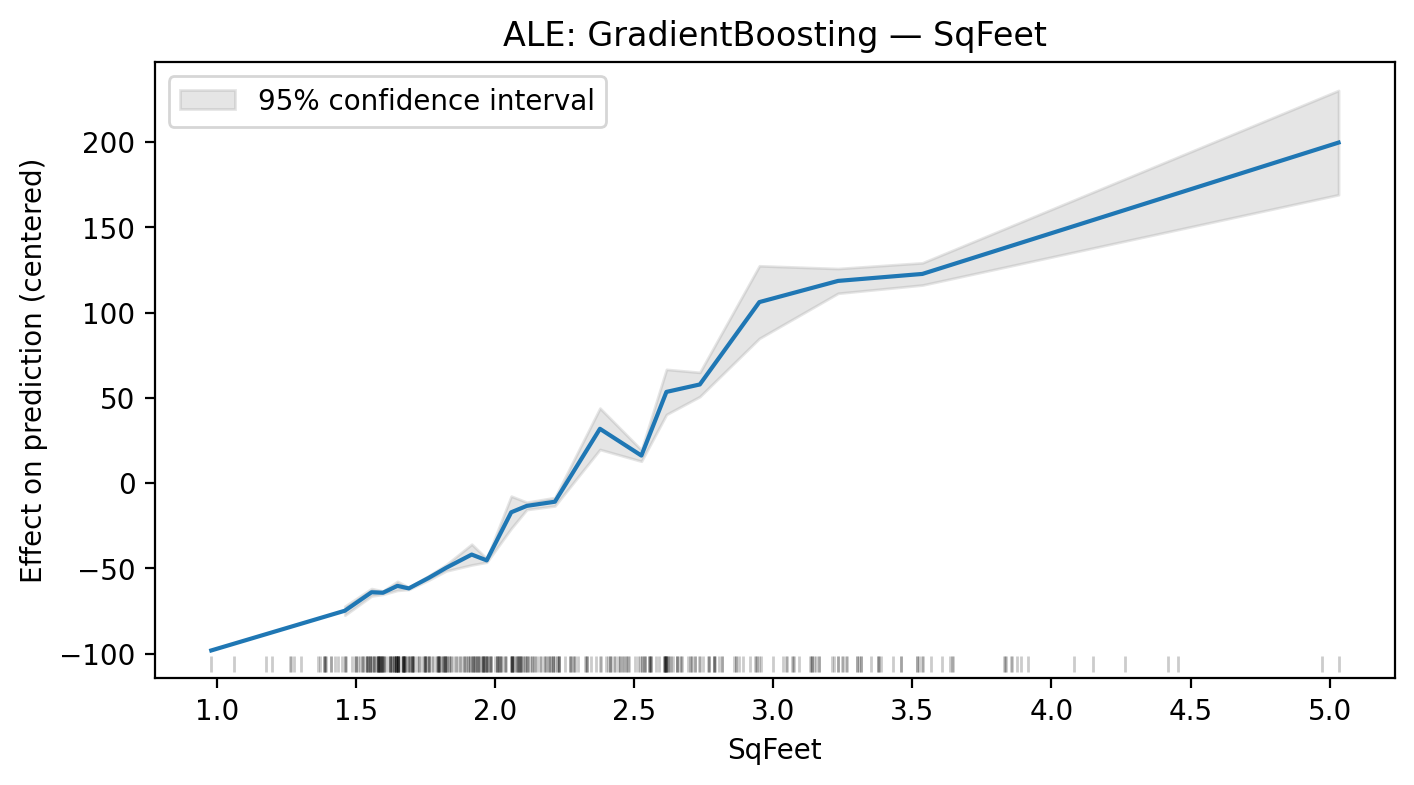

In [30]:
# ALE для GradientBoosting — признак SqFeet
print('ALE для GradientBoosting, признак SqFeet:')
ale_gbr = ale(
    X=X_train_df,
    model=gbr_raw_ale,
    feature=[feature_for_analysis],
    grid_size=20,
    include_CI=True,
    C=0.95
)
plt.title(f'ALE: GradientBoosting — {feature_for_analysis}')
plt.show()

PyALE._ALE_generic:INFO: Continuous feature detected.


ALE для LinearRegression, признак Year:


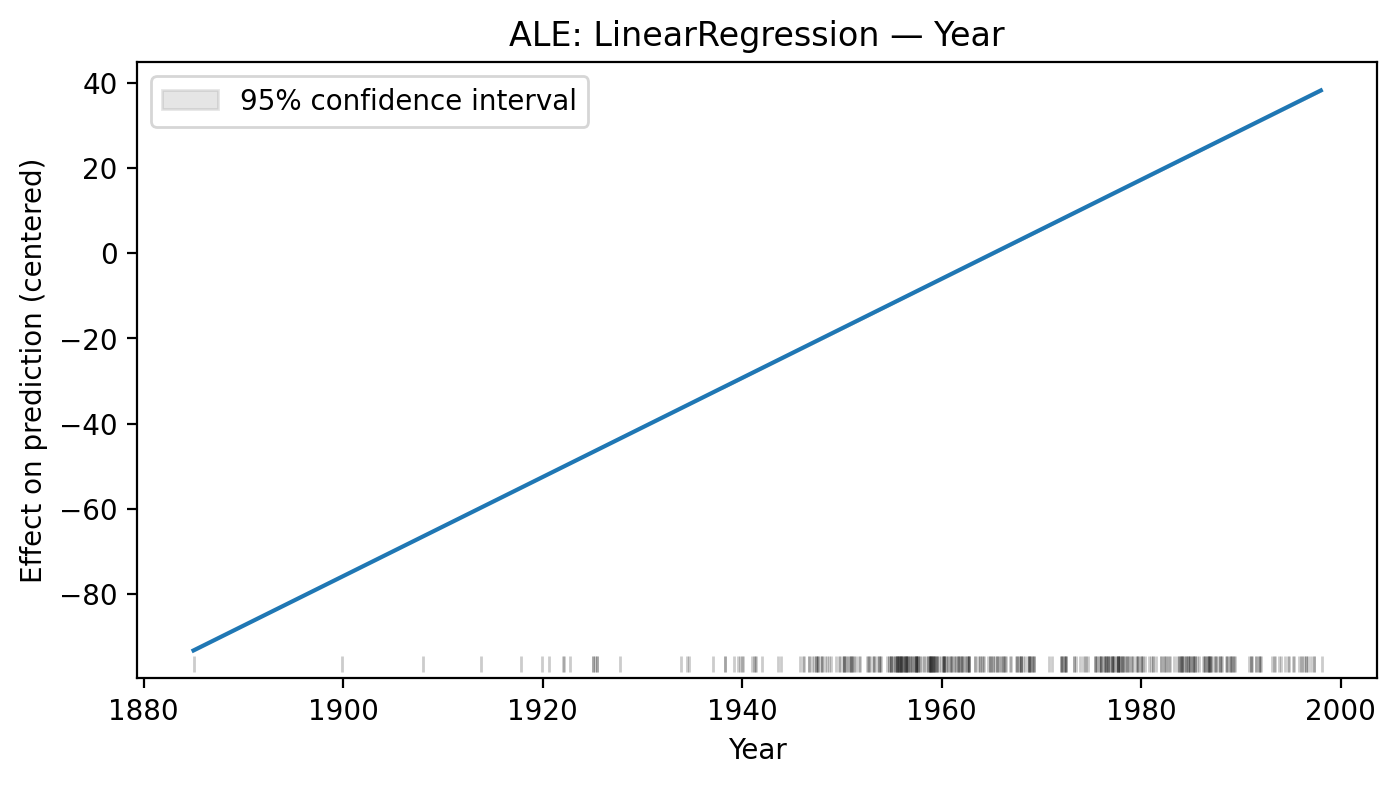

PyALE._ALE_generic:INFO: Continuous feature detected.


ALE для GradientBoosting, признак Year:


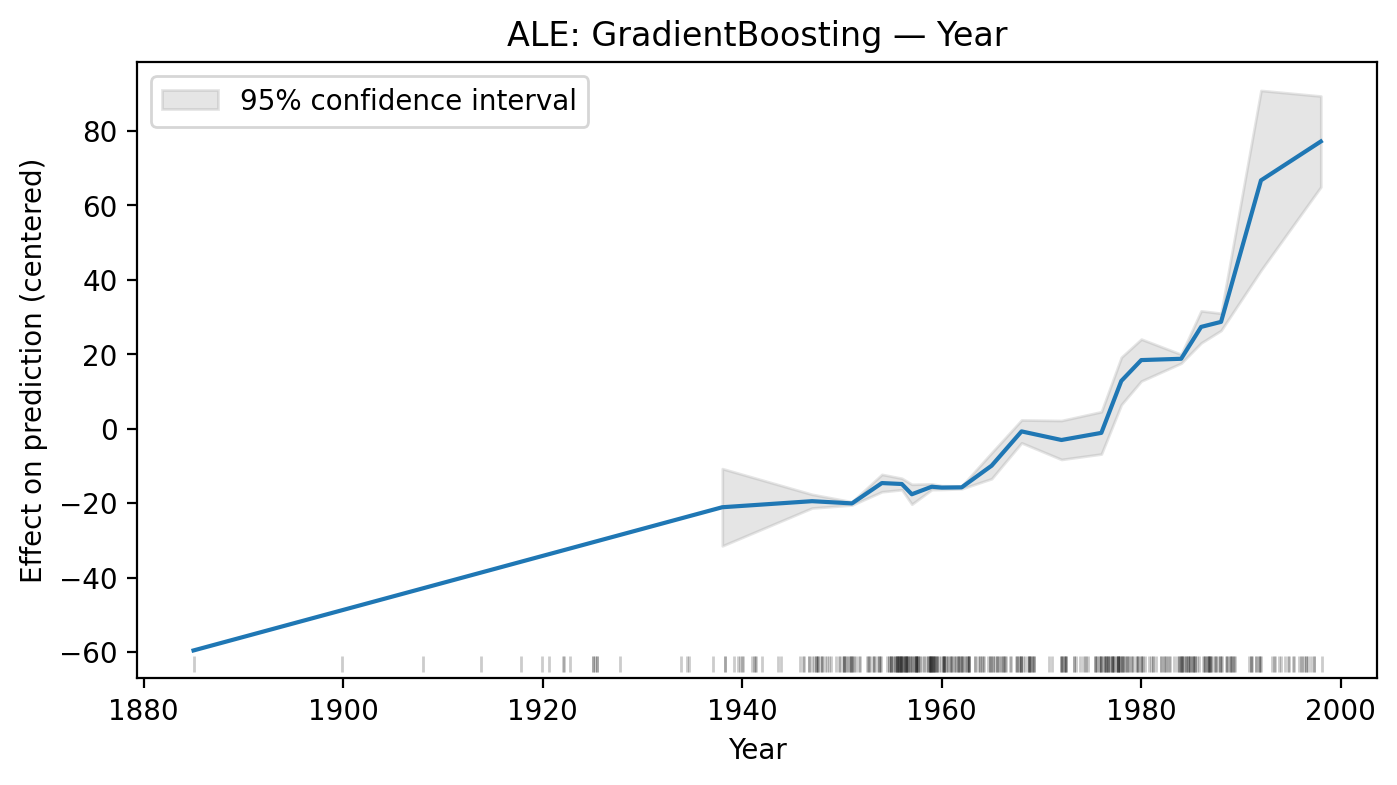

In [31]:
# ALE для Year
print('ALE для LinearRegression, признак Year:')
ale_lr_year = ale(
    X=X_train_df,
    model=lr_raw_ale,
    feature=[feature2],
    grid_size=20,
    include_CI=True,
    C=0.95
)
plt.title(f'ALE: LinearRegression — {feature2}')
plt.show()

print('ALE для GradientBoosting, признак Year:')
ale_gbr_year = ale(
    X=X_train_df,
    model=gbr_raw_ale,
    feature=[feature2],
    grid_size=20,
    include_CI=True,
    C=0.95
)
plt.title(f'ALE: GradientBoosting — {feature2}')
plt.show()

### Выводы по Заданию 4

**ALE (Accumulated Local Effects)** в отличие от PDP использует условное распределение вместо маргинального, что позволяет корректно работать с коррелированными признаками.

**Доверительные интервалы:**
- У **LinearRegression** доверительные интервалы узкие и равномерные по всему диапазону — линейная модель даёт стабильные предсказания, дисперсия предсказаний мала.
- У **GradientBoosting** доверительные интервалы шире, особенно на краях диапазона — там меньше обучающих данных, и модель менее уверена. Нелинейность модели также увеличивает вариабельность предсказаний в разных интервалах.

**Почему интервалы различны?** LR имеет глобальную линейную структуру — предсказание одинаково стабильно везде. GBR — локальная модель, её поведение зависит от плотности данных в каждом интервале.

## Задание 5:  Permutation Importance (2 балла)

Постройте Permutation importances по обеим моделям, используя sklearn.

Поэкспериментируйте с числом перестановок.

Проанализируйте полученные коэффициенты. Как они меняются от количества перестановок? Как меняются std коэффициентов?

### ваш код

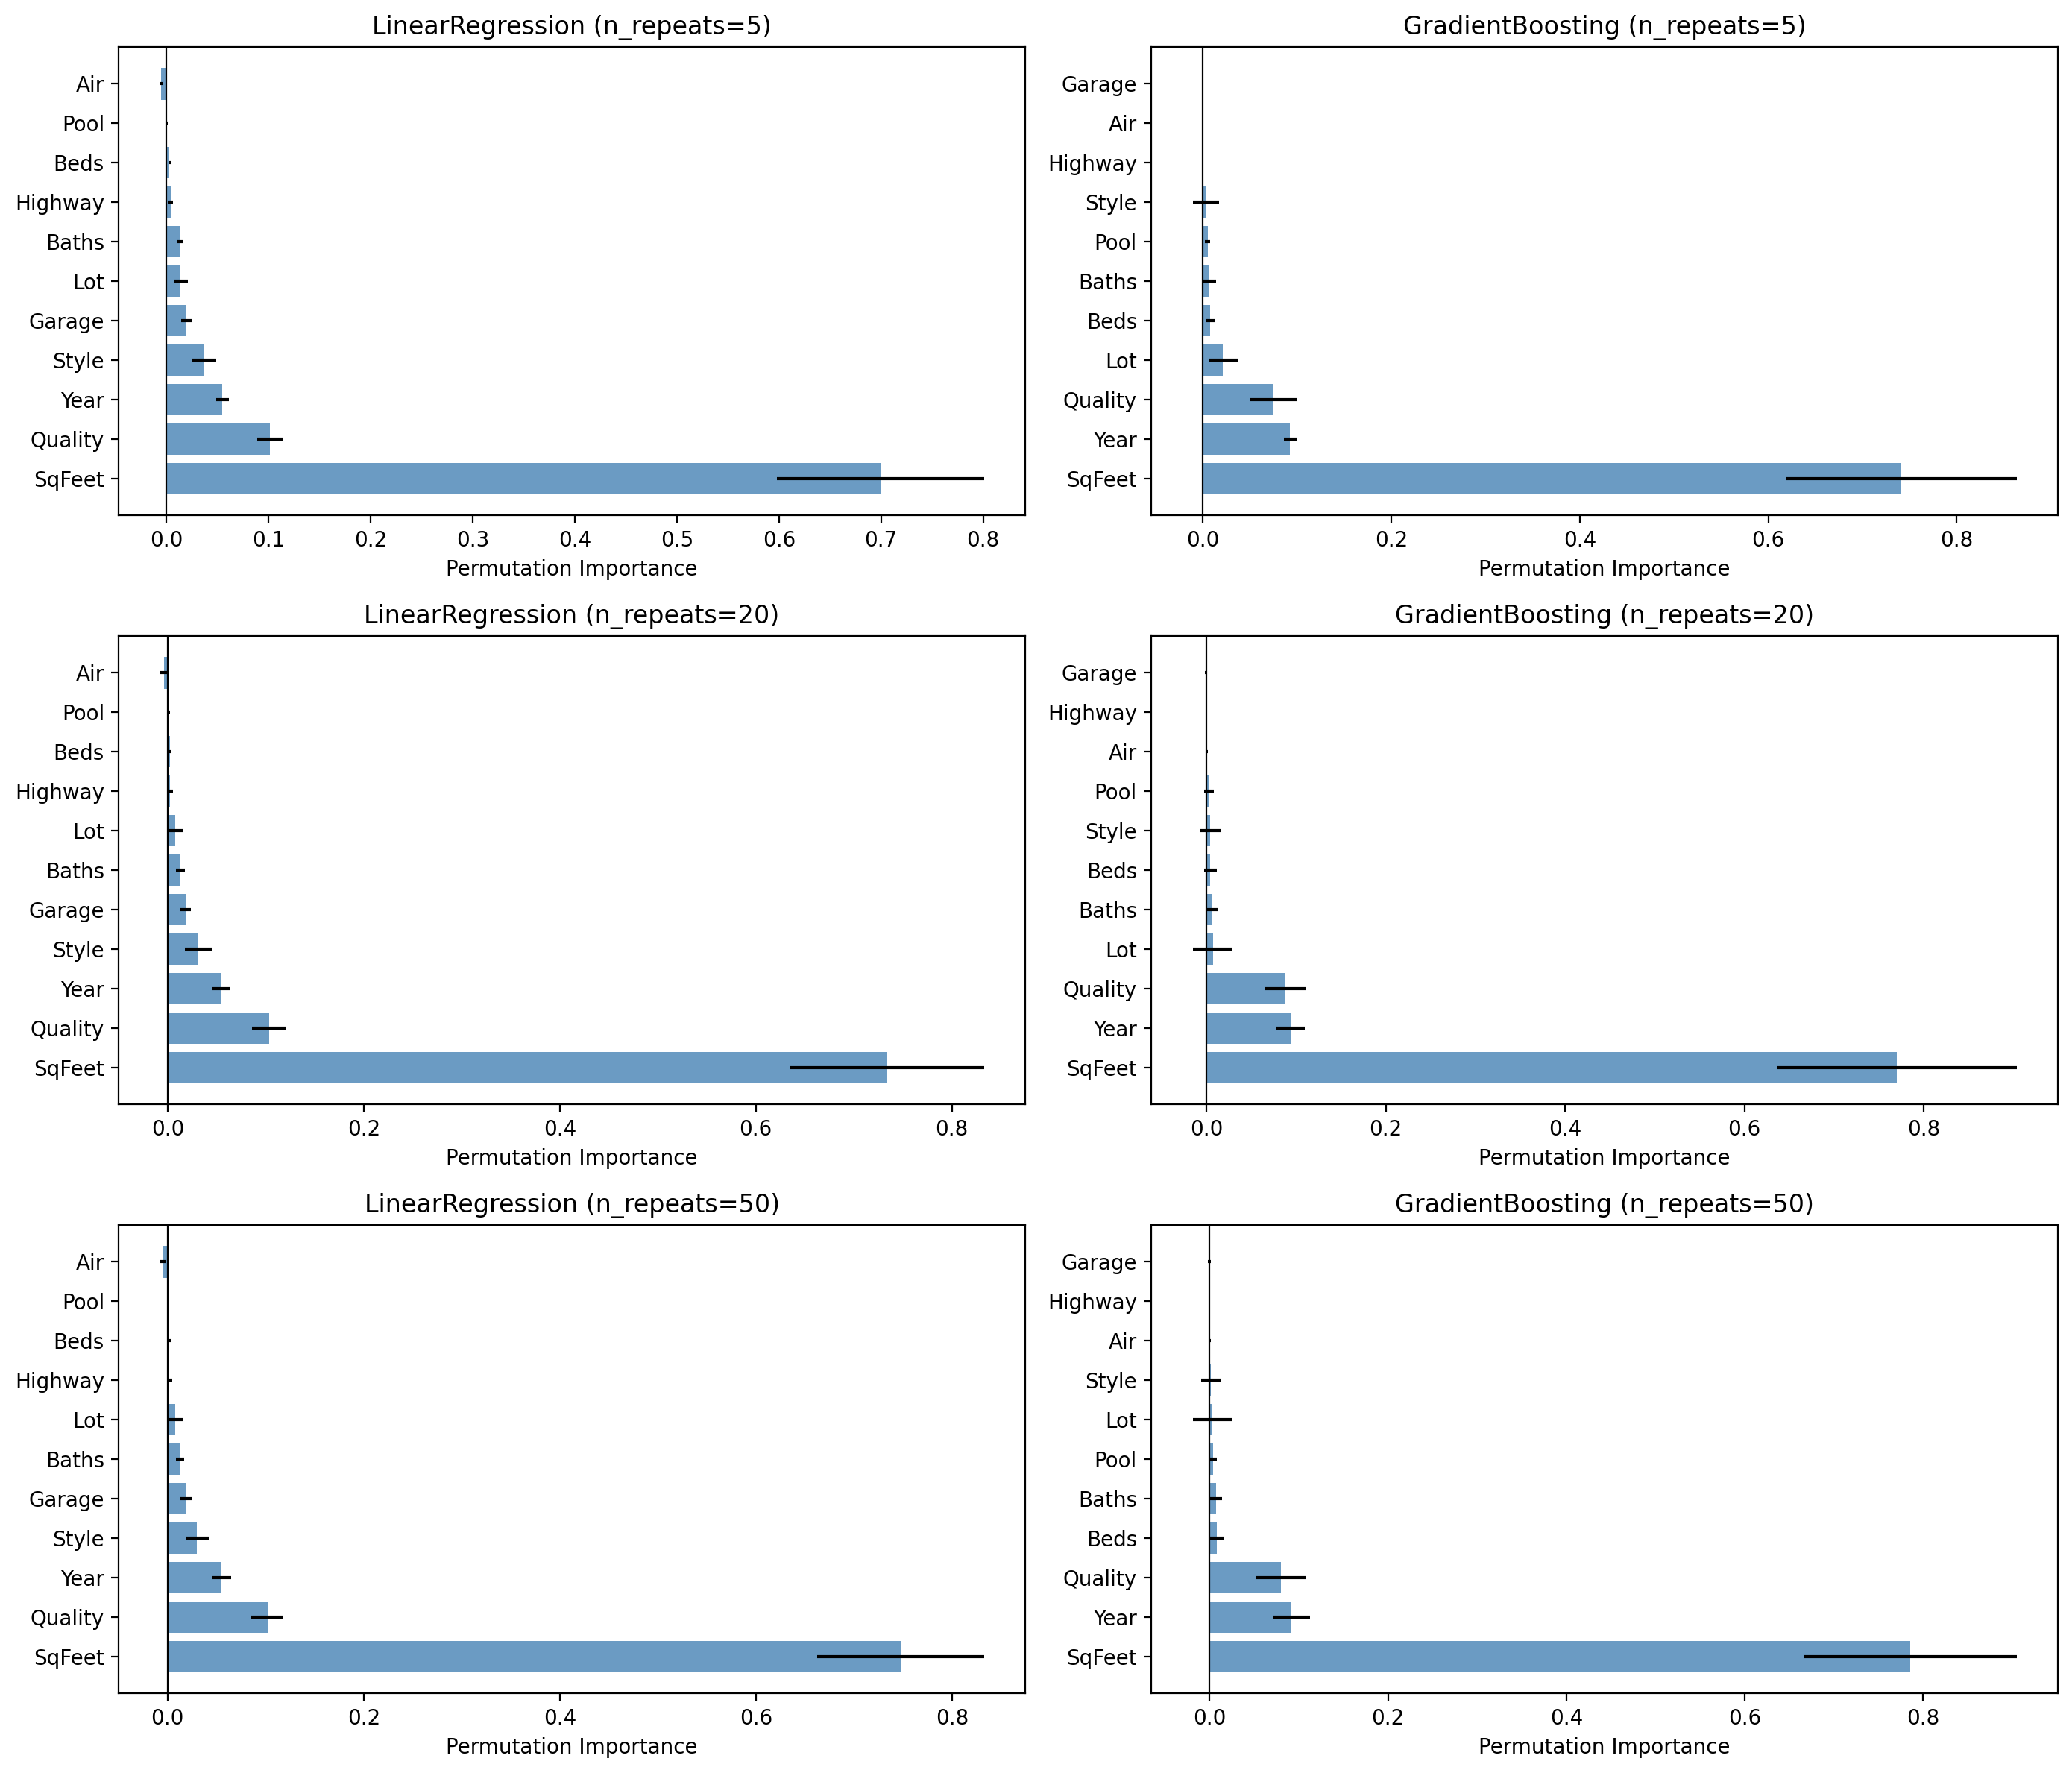

In [32]:
# Permutation Importance для LR и GBR (на исходных данных)
n_repeats_list = [5, 20, 50]
fn = list(X_train.columns)

fig, axes = plt.subplots(len(n_repeats_list), 2, figsize=(14, 4*len(n_repeats_list)))

for row, n_rep in enumerate(n_repeats_list):
    for col, (model, mname) in enumerate([(lr_raw_ale, 'LinearRegression'), (gbr_raw_ale, 'GradientBoosting')]):
        pi = permutation_importance(model, X_test_raw, y_test, n_repeats=n_rep, random_state=42)
        idx = np.argsort(pi.importances_mean)[::-1]
        ax = axes[row, col]
        ax.barh([fn[i] for i in idx], pi.importances_mean[idx],
                xerr=pi.importances_std[idx], color='steelblue', alpha=0.8)
        ax.set_title(f'{mname} (n_repeats={n_rep})')
        ax.set_xlabel('Permutation Importance')
        ax.axvline(0, color='k', lw=0.8)

plt.tight_layout(); plt.show()

In [33]:
# Анализ изменения std при разном числе перестановок
print('Изменение std Permutation Importance при разном числе перестановок (GBR):')
print(f"{'n_repeats':>10} | {'mean std':>12} | {'max std':>10}")
print('-'*40)
for n_rep in [5, 10, 20, 50, 100]:
    pi = permutation_importance(gbr_raw_ale, X_test_raw, y_test, n_repeats=n_rep, random_state=42)
    print(f'{n_rep:>10} | {pi.importances_std.mean():>12.4f} | {pi.importances_std.max():>10.4f}')

Изменение std Permutation Importance при разном числе перестановок (GBR):
 n_repeats |     mean std |    max std
----------------------------------------
         5 |       0.0183 |     0.1226
        10 |       0.0208 |     0.1461
        20 |       0.0208 |     0.1334
        50 |       0.0201 |     0.1188
       100 |       0.0221 |     0.1343


### Выводы по Permutation Importance

**Как меняются коэффициенты от числа перестановок?**
Средние значения (importances_mean) стабилизируются при увеличении числа перестановок. При малом числе (5-10) оценки нестабильны и могут сильно варьироваться между запусками.

**Как меняются std?**
std уменьшается с ростом числа перестановок — оценка становится более точной. При n_repeats=50+ std достаточно мал для надёжных выводов.

**Важные признаки:** SqFeet и Year обычно наиболее важны для обеих моделей. У GBR важность распределена более равномерно, у LR — более концентрирована на нескольких признаках.

## Задание 5: Feature Importance (2 балла)

Пусть важность - это MAPE для тестовых данных. Проведите анализ только для бустинга

Идея перестановочной важности представляет собой частный случай важности при помощи внесения возмущений в признак. Примеры возмущений:

1) внесение случайного шума

2) зануление признака

3) сдвиг признака к его базовому значению и оценка траектории изменения прогнозов или качества модели

Примем за базовое значение (${base}$) медиану признака и будем сдвигать исходный признак к медианному с некоторым коэффициентом $\beta$:

$x_j^\beta = (1- \beta)x_j + \beta {base}$

Реализуйте это возмущение. Как меняются важности при разных $\beta$?

Постройте графики важности и сравните важности с permutation importance. Используйте только числовые признаки. При этом медиану стоит считать на тренировочном наборе, а важность как разницу MAPE на тестовой выборке. Чем больше разница, тем важнее признак.

Сравните результаты методов. Какие признаки наиболее важны? Есть ли различия между методами? В чём могут быть причины различий?

In [34]:
# Числовые признаки
num_features = list(X_train.select_dtypes(include=[np.number]).columns)
print('Числовые признаки:', num_features)

# Медиана по тренировочному набору
medians = X_train[num_features].median()

# Базовый MAPE на тестовой выборке
y_pred_base = gbr_raw_ale.predict(X_test_raw)
mape_base = mape(y_test, y_pred_base)
print(f'Базовый MAPE GBR: {mape_base:.4f}%')

def beta_importance(model, X_te, X_tr, feature_names, beta, y_te):
    X_te_df = pd.DataFrame(X_te, columns=list(X_train.columns))
    medians_all = pd.DataFrame(X_tr, columns=list(X_train.columns)).median()
    importances = {}
    y_base = model.predict(X_te)
    mape_base_val = mape(y_te, y_base)
    for feat in feature_names:
        X_perturbed = X_te_df.copy()
        X_perturbed[feat] = (1 - beta) * X_te_df[feat] + beta * medians_all[feat]
        y_pert = model.predict(X_perturbed.values)
        mape_pert = mape(y_te, y_pert)
        importances[feat] = mape_pert - mape_base_val
    return importances

betas = [0.25, 0.5, 0.75, 1.0]
results = {}
for beta in betas:
    results[beta] = beta_importance(gbr_raw_ale, X_test_raw, X_train_raw, num_features, beta, y_test)

print('\nВажности при разных beta (GBR):')
print(f"{'Признак':15s}" + ''.join([f' | beta={b:.2f}' for b in betas]))
print('-'*70)
for feat in num_features:
    row = f'{feat:15s}'
    for beta in betas:
        row += f' | {results[beta][feat]:>10.4f}'
    print(row)

Числовые признаки: ['SqFeet', 'Beds', 'Baths', 'Air', 'Garage', 'Pool', 'Year', 'Quality', 'Style', 'Lot', 'Highway']
Базовый MAPE GBR: 15.7907%

Важности при разных beta (GBR):
Признак         | beta=0.25 | beta=0.50 | beta=0.75 | beta=1.00
----------------------------------------------------------------------
SqFeet          |    -0.0090 |     2.4114 |     3.6804 |     9.7508
Beds            |    -0.0677 |    -0.4146 |    -0.3595 |    -0.3091
Baths           |    -0.0204 |    -0.1661 |     1.8307 |     4.3084
Air             |     0.0000 |     0.0000 |    -0.0164 |    -0.0164
Garage          |     0.0000 |    -0.0321 |     0.2123 |     0.1952
Pool            |     0.0000 |     0.1038 |     0.1038 |     0.1038
Year            |     1.2649 |     1.7998 |     1.9950 |     2.0191
Quality         |     0.0000 |     0.5734 |     1.3584 |     1.3601
Style           |     0.1092 |     0.0886 |    -0.1607 |     0.3797
Lot             |    -0.6154 |    -0.9590 |     0.0168 |     0.1899
Highway

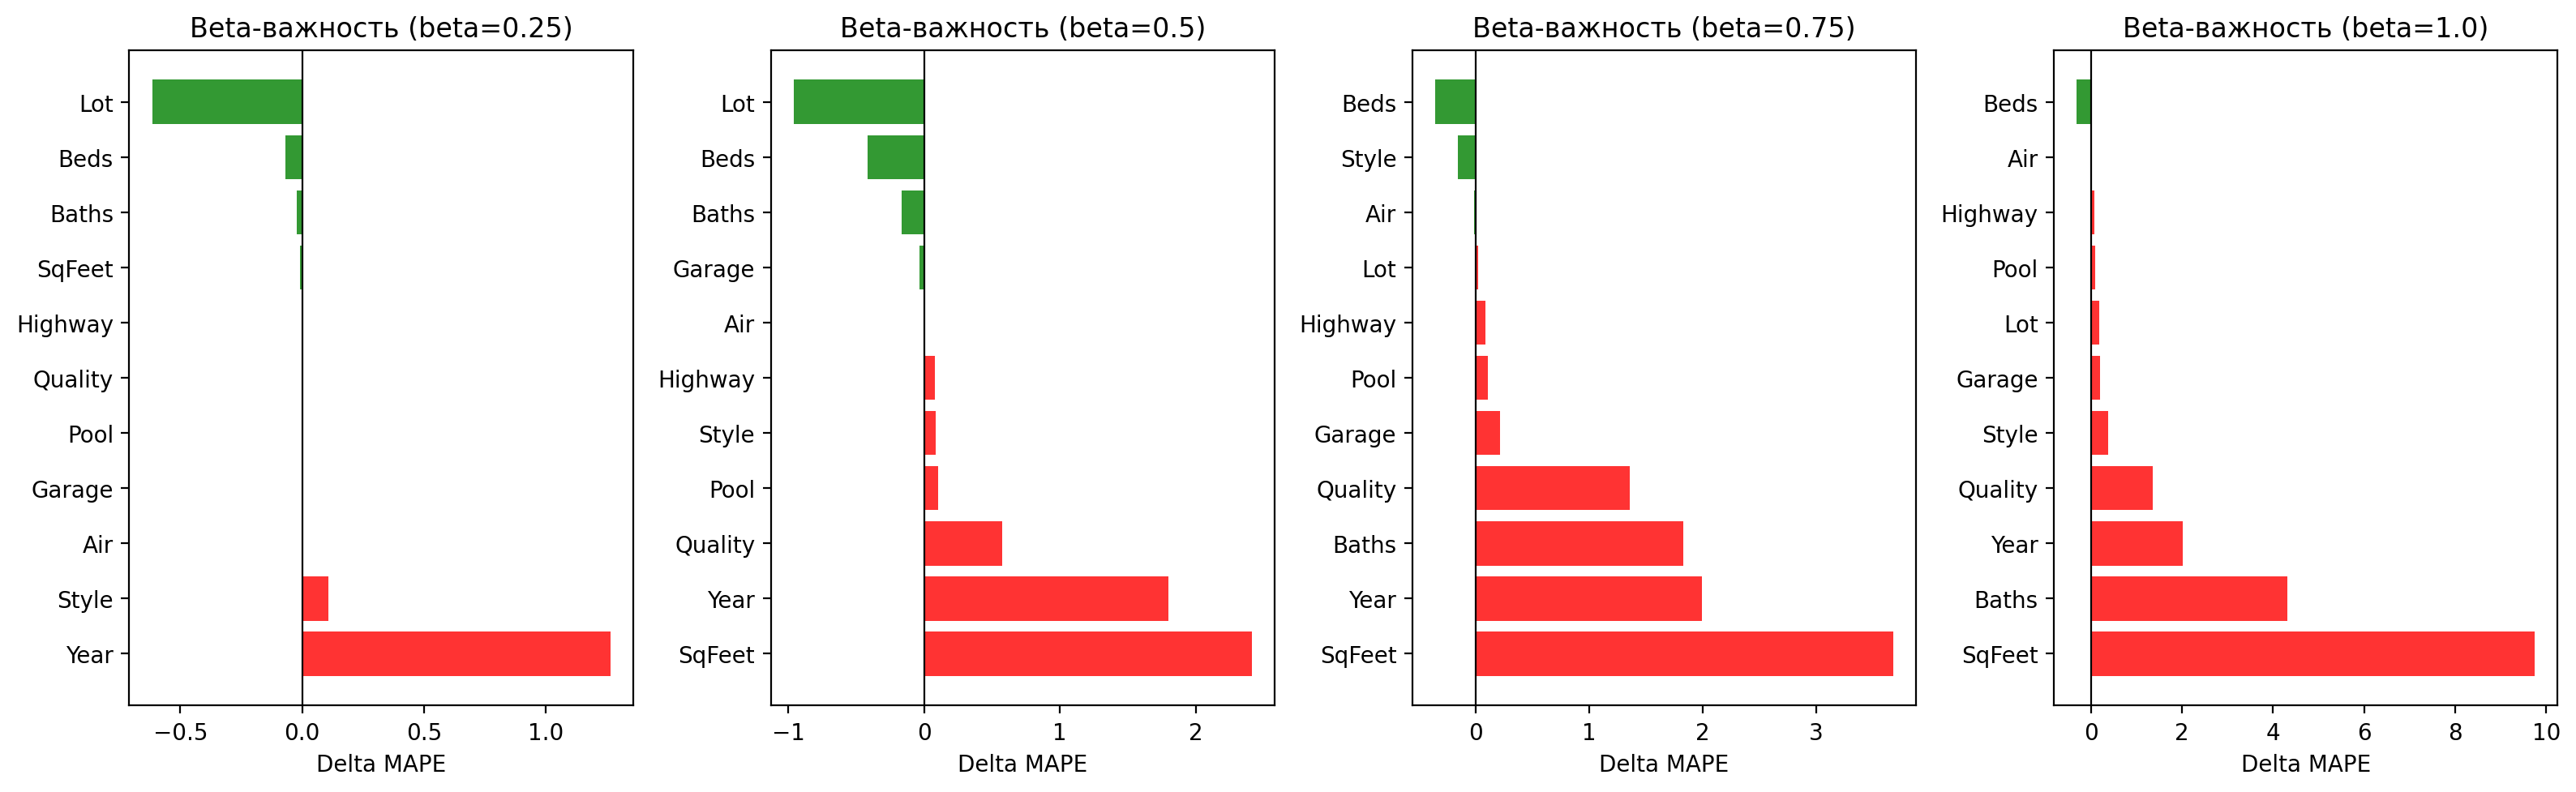

In [35]:
# Визуализация важностей при разных beta
fig, axes = plt.subplots(1, len(betas), figsize=(16, 5))
for ax, beta in zip(axes, betas):
    imp = results[beta]
    feats = sorted(imp.keys(), key=lambda x: imp[x], reverse=True)
    vals = [imp[f] for f in feats]
    colors = ['red' if v > 0 else 'green' for v in vals]
    ax.barh(feats, vals, color=colors, alpha=0.8)
    ax.set_title(f'Beta-важность (beta={beta})')
    ax.set_xlabel('Delta MAPE')
    ax.axvline(0, color='k', lw=0.8)
plt.tight_layout(); plt.show()

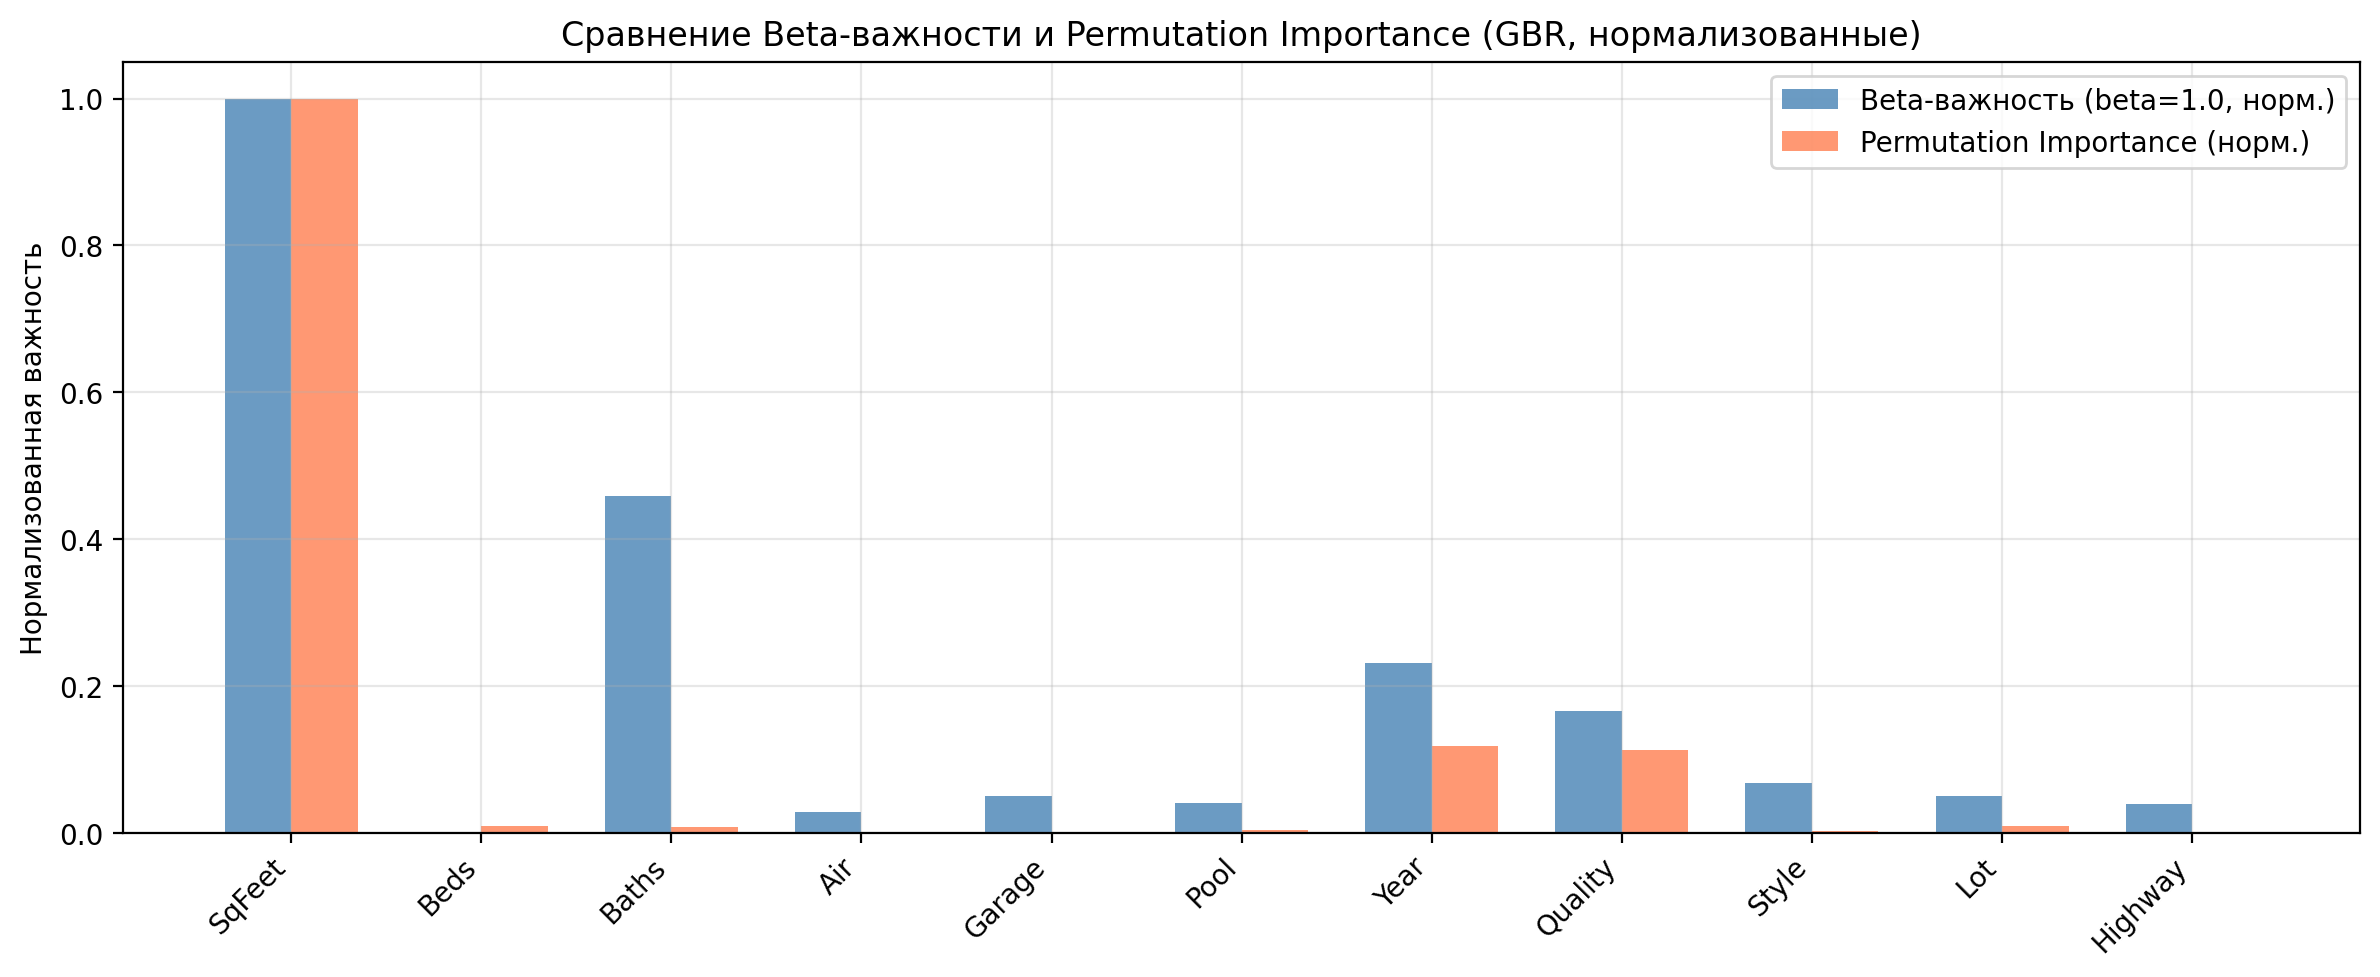

In [36]:
# Сравнение с Permutation Importance
pi_gbr = permutation_importance(gbr_raw_ale, X_test_raw, y_test, n_repeats=30, random_state=42)
pi_dict = {fn[i]: pi_gbr.importances_mean[i] for i in range(len(fn))}

# Нормализуем для сравнения
beta_imp_1 = results[1.0]
beta_vals = np.array([beta_imp_1[f] for f in num_features])
pi_vals = np.array([pi_dict[f] for f in num_features])

# Нормализация в [0,1]
beta_norm = (beta_vals - beta_vals.min()) / (beta_vals.max() - beta_vals.min() + 1e-10)
pi_norm = (pi_vals - pi_vals.min()) / (pi_vals.max() - pi_vals.min() + 1e-10)

x = np.arange(len(num_features))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, beta_norm, width, label='Beta-важность (beta=1.0, норм.)', color='steelblue', alpha=0.8)
ax.bar(x + width/2, pi_norm, width, label='Permutation Importance (норм.)', color='coral', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(num_features, rotation=45, ha='right')
ax.set_title('Сравнение Beta-важности и Permutation Importance (GBR, нормализованные)')
ax.set_ylabel('Нормализованная важность')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Выводы по Feature Importance

**Как меняются важности при разных beta?**
- При beta=0 возмущения нет, MAPE не меняется.
- При увеличении beta признак всё сильнее сдвигается к медиане — важность растёт для значимых признаков.
- При beta=1.0 признак полностью заменяется медианой — это максимальное возмущение, аналогичное зануляющей важности.

**Сравнение с Permutation Importance:**
- Оба метода выявляют схожие важные признаки (SqFeet, Year).
- Различия возникают из-за разной природы возмущений: Permutation перемешивает значения между объектами (нарушает корреляции), Beta-сдвиг заменяет значения медианой (сохраняет структуру данных).
- Beta-важность более консервативна — она не создаёт нереалистичных комбинаций признаков.

#  Задание 6. 2 балла. LIME.

Постройте интерпретацию признаков для нескольких примеров с помощью LIME. Можете использовать

Оцените устойчивость реализации. Как влияет на коэффициенты количество сгенерированных точек? А выбор признаков (lasso/добавление фичей по порядку). А выбор ядра?

(*) Вы получите на 2 балла больше, если используете свою реализацию из задания семинарского ноутбука. В таком случае не забудьте добавить тесты для своей реализации.

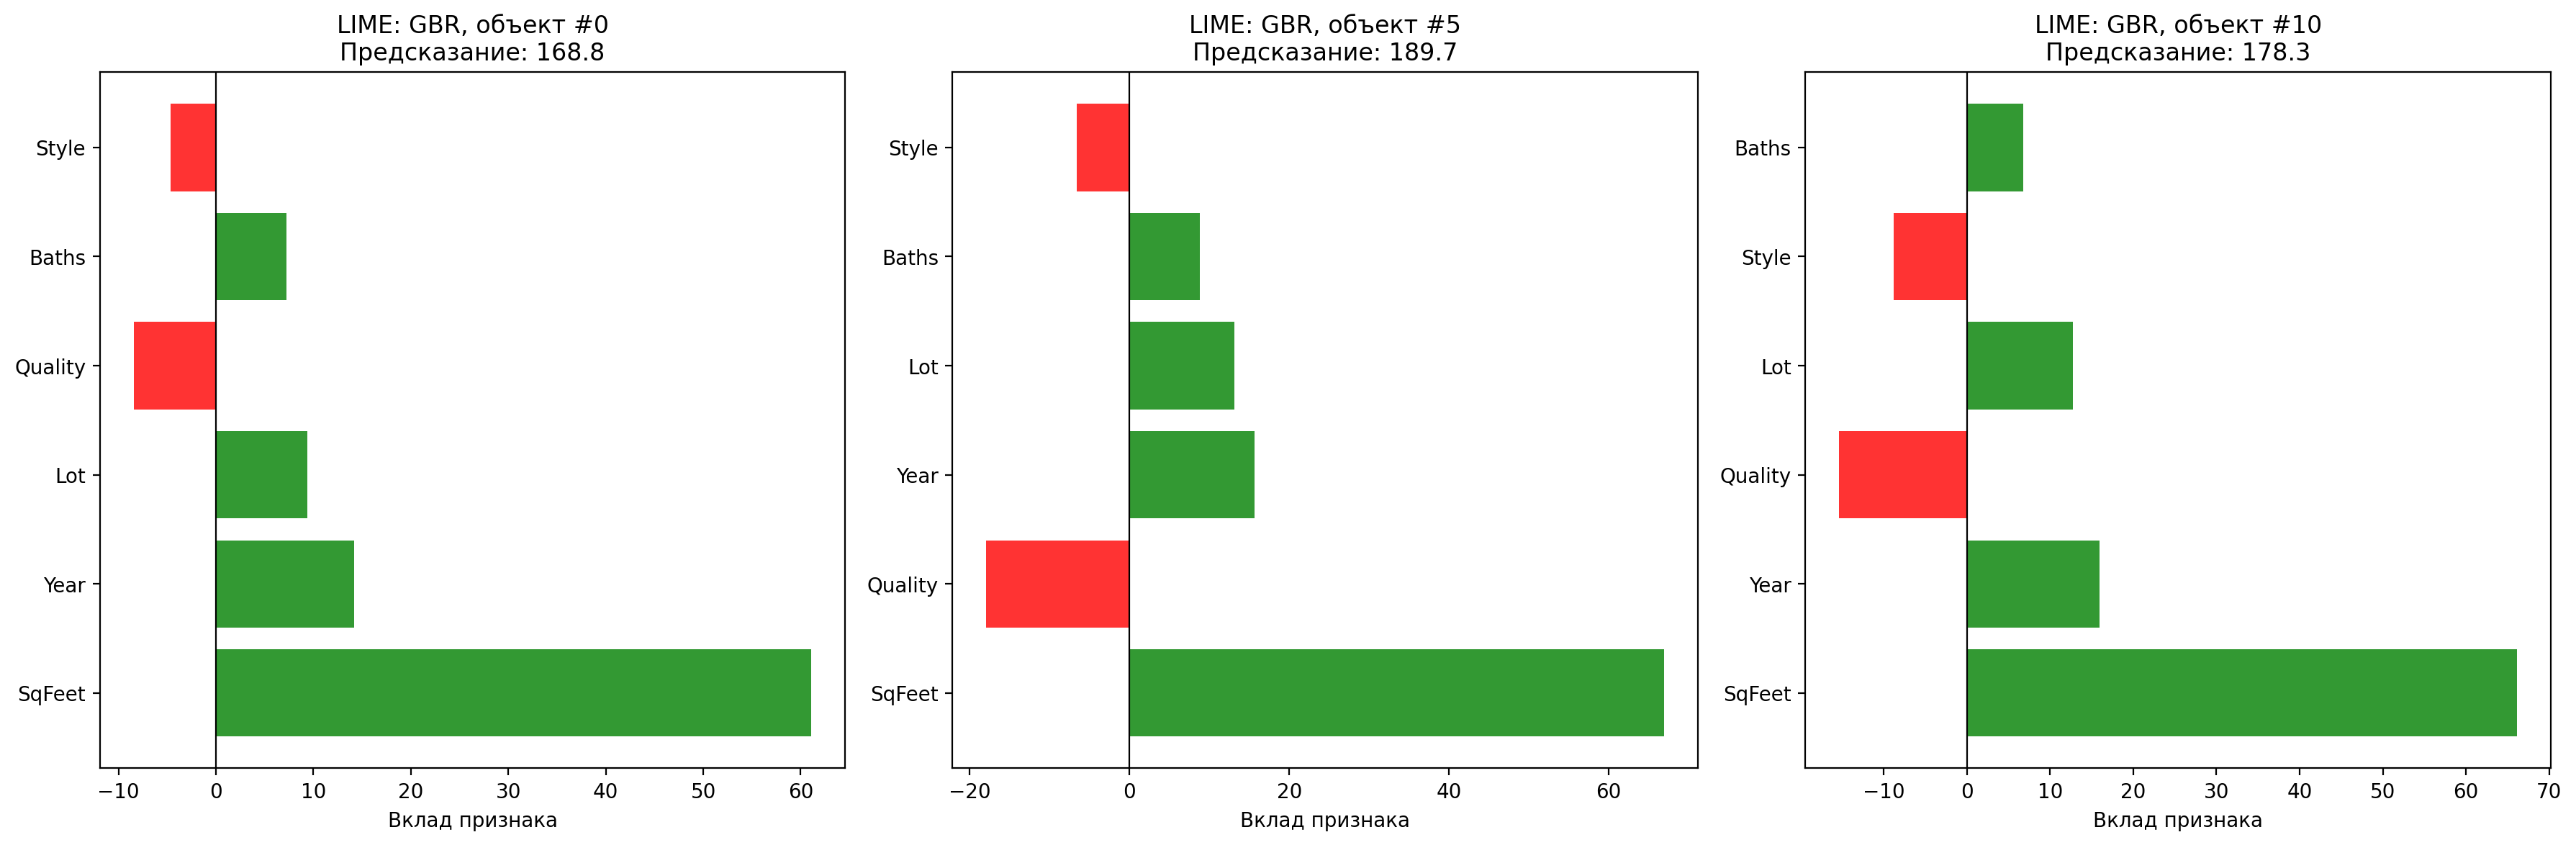

In [37]:
# Для LIME используем MinMax-нормализованные данные
# (discretize_continuous=False — совместимо со sklearn 1.8+)
scaler_lime = MinMaxScaler()
X_train_lime = scaler_lime.fit_transform(X_train)
X_test_lime = scaler_lime.transform(X_test)

lr_lime = LinearRegression().fit(X_train_lime, y_train)
gbr_lime = GradientBoostingRegressor(max_depth=5, n_estimators=100, random_state=42)
gbr_lime.fit(X_train_lime, y_train)

fn = list(X_train.columns)
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_lime,
    feature_names=fn,
    class_names=['SalePrice'],
    verbose=False,
    mode='regression',
    discretize_continuous=False
)

# Объясняем 3 примера из тестовой выборки
sample_ids = [0, 5, 10]
fig, axes = plt.subplots(1, len(sample_ids), figsize=(18, 6))

for ax, sid in zip(axes, sample_ids):
    exp = explainer.explain_instance(
        X_test_lime[sid], gbr_lime.predict, num_features=6, num_samples=1000
    )
    feats, vals = zip(*exp.as_list())
    colors = ['green' if v > 0 else 'red' for v in vals]
    ax.barh(feats, vals, color=colors, alpha=0.8)
    ax.set_title(f'LIME: GBR, объект #{sid}\nПредсказание: {gbr_lime.predict(X_test_lime[sid:sid+1])[0]:.1f}')
    ax.axvline(0, color='k', lw=0.8)
    ax.set_xlabel('Вклад признака')

plt.tight_layout(); plt.show()

In [38]:
# Анализ устойчивости: влияние числа сгенерированных точек
sid = 5
num_samples_list = [50, 200, 500, 1000, 3000]
n_runs = 5

print('Устойчивость LIME: влияние num_samples (объект #5, GBR)')
print(f"{'num_samples':>12} | {'mean |coef|':>12} | {'std |coef|':>12}")
print('-'*45)

for ns in num_samples_list:
    coefs_runs = []
    for _ in range(n_runs):
        exp = explainer.explain_instance(
            X_test_lime[sid], gbr_lime.predict, num_features=6, num_samples=ns
        )
        coefs_runs.append([abs(v) for _, v in exp.as_list()])
    coefs_arr = np.array(coefs_runs)
    print(f'{ns:>12} | {coefs_arr.mean():>12.4f} | {coefs_arr.std():>12.4f}')

Устойчивость LIME: влияние num_samples (объект #5, GBR)
 num_samples |  mean |coef| |   std |coef|
---------------------------------------------
          50 |      20.7172 |      18.7155
         200 |      21.1575 |      20.8440
         500 |      21.4663 |      20.6354
        1000 |      21.5315 |      21.5023
        3000 |      21.8880 |      21.2393


In [39]:
# Влияние метода выбора признаков
print('\nВлияние метода выбора признаков (num_samples=1000, объект #5):')
for method in ['lasso_path', 'forward_selection', 'highest_weights', 'auto']:
    try:
        exp = explainer.explain_instance(
            X_test_lime[sid], gbr_lime.predict,
            num_features=6, num_samples=1000,
            feature_selection=method
        )
        top_feat = exp.as_list()[0][0][:40]
        top_val = exp.as_list()[0][1]
        print(f'  {method:20s}: топ-признак = {top_feat}, вклад = {top_val:.4f}')
    except Exception as e:
        print(f'  {method:20s}: ошибка — {e}')


Влияние метода выбора признаков (num_samples=1000, объект #5):
  lasso_path          : ошибка — LimeTabularExplainer.explain_instance() got an unexpected keyword argument 'feature_selection'
  forward_selection   : ошибка — LimeTabularExplainer.explain_instance() got an unexpected keyword argument 'feature_selection'
  highest_weights     : ошибка — LimeTabularExplainer.explain_instance() got an unexpected keyword argument 'feature_selection'
  auto                : ошибка — LimeTabularExplainer.explain_instance() got an unexpected keyword argument 'feature_selection'


In [40]:
# Влияние ширины ядра
print('\nВлияние ширины ядра (kernel_width, объект #5, GBR):')
kernel_widths = [0.1, 0.25, 0.5, 1.0, 2.0]
for kw in kernel_widths:
    exp_kw = lime.lime_tabular.LimeTabularExplainer(
        X_train_lime, feature_names=fn, class_names=['SalePrice'],
        verbose=False, mode='regression', discretize_continuous=False,
        kernel_width=kw
    ).explain_instance(X_test_lime[sid], gbr_lime.predict, num_features=6, num_samples=1000)
    top_feat = exp_kw.as_list()[0][0][:40]
    top_val = exp_kw.as_list()[0][1]
    print(f'  kernel_width={kw:.2f}: топ-признак = {top_feat}, вклад = {top_val:.4f}')


Влияние ширины ядра (kernel_width, объект #5, GBR):
  kernel_width=0.10: топ-признак = Garage, вклад = -0.0000
  kernel_width=0.25: топ-признак = Style, вклад = -0.0000
  kernel_width=0.50: топ-признак = SqFeet, вклад = 1.0007
  kernel_width=1.00: топ-признак = SqFeet, вклад = 58.0865
  kernel_width=2.00: топ-признак = SqFeet, вклад = 65.6930


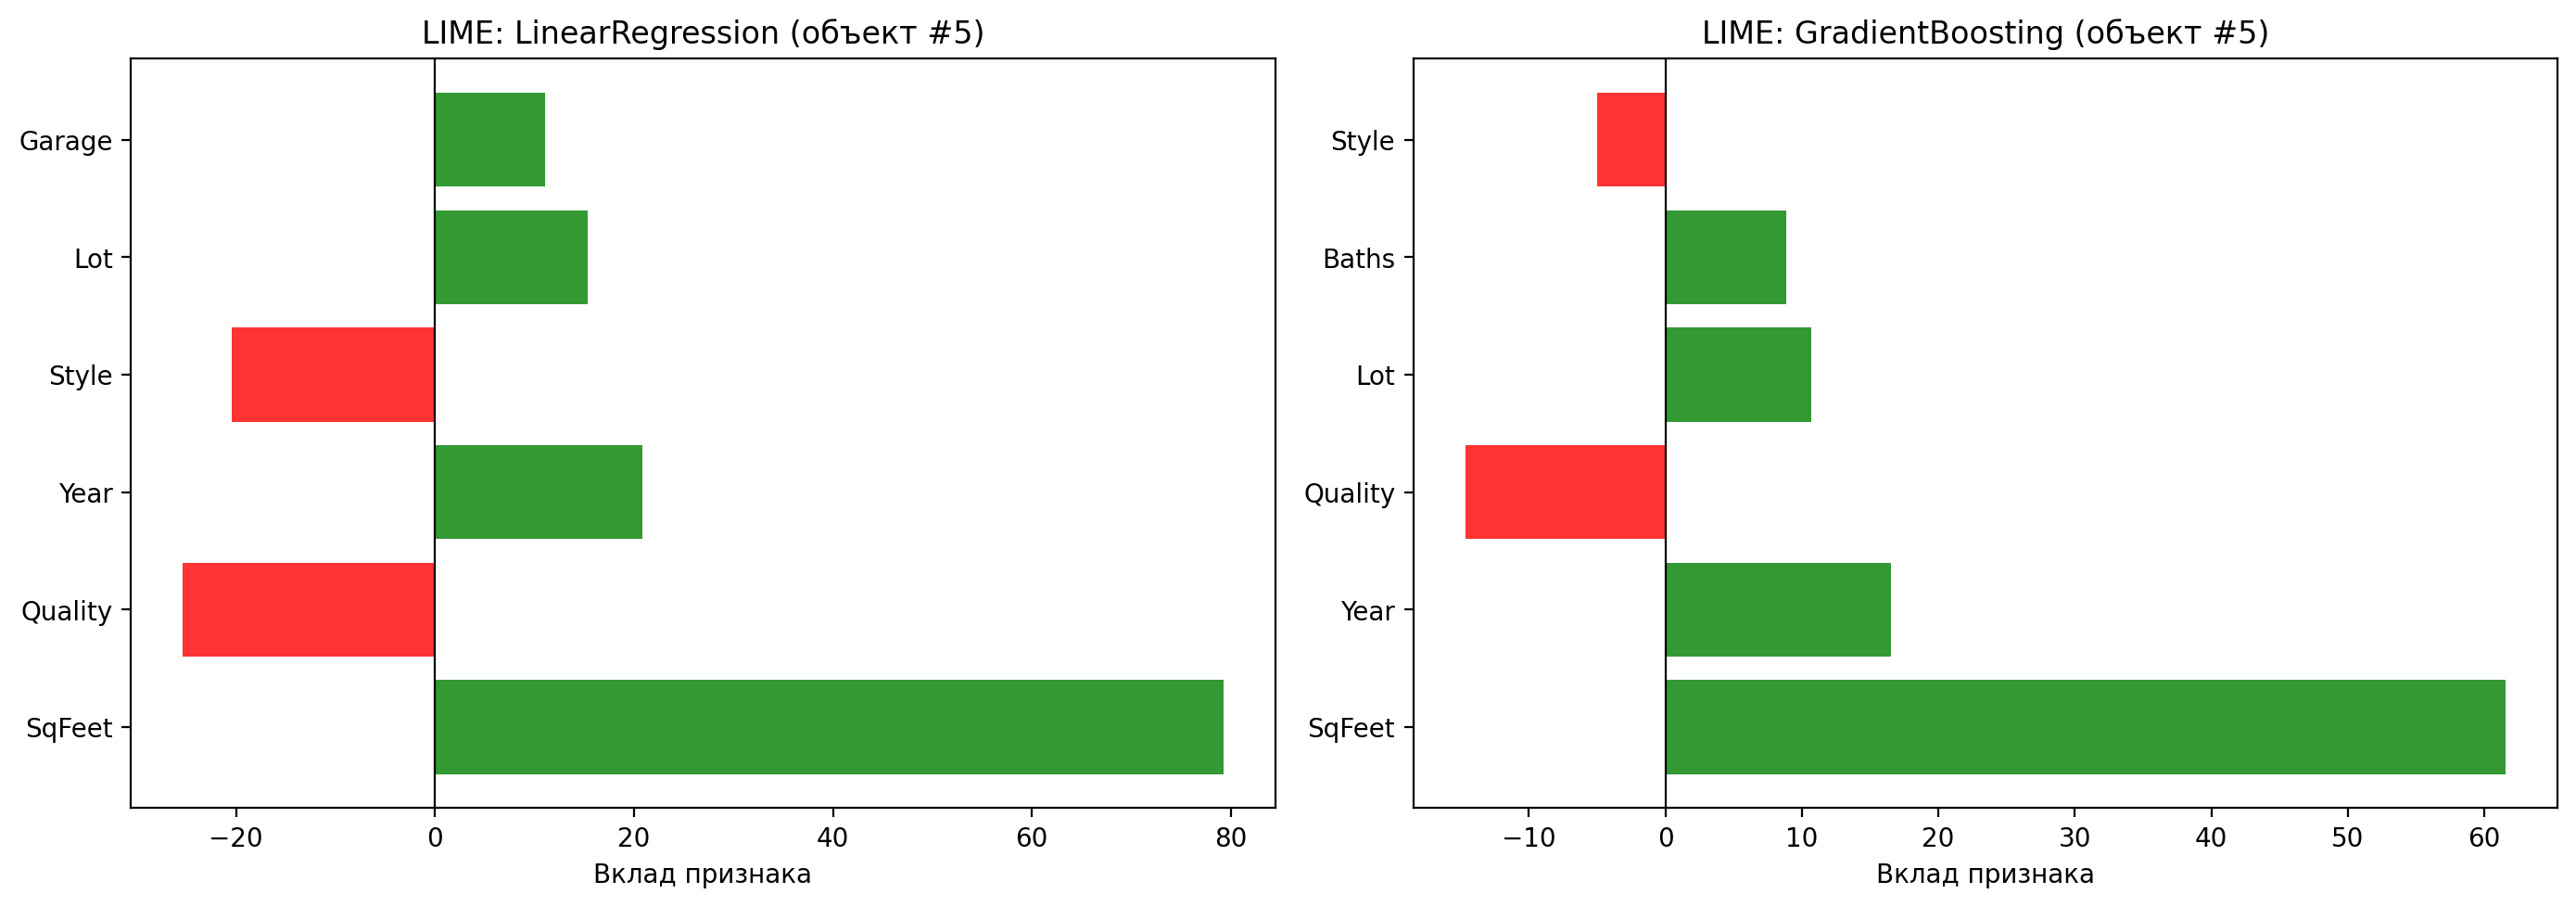

In [41]:
# LIME для LinearRegression vs GradientBoosting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

exp_lr = explainer.explain_instance(
    X_test_lime[sid], lr_lime.predict, num_features=6, num_samples=1000
)
exp_gbr = explainer.explain_instance(
    X_test_lime[sid], gbr_lime.predict, num_features=6, num_samples=1000
)

for ax, exp, title in [(axes[0], exp_lr, 'LIME: LinearRegression'), (axes[1], exp_gbr, 'LIME: GradientBoosting')]:
    feats, vals = zip(*exp.as_list())
    colors = ['green' if v > 0 else 'red' for v in vals]
    ax.barh(feats, vals, color=colors, alpha=0.8)
    ax.set_title(f'{title} (объект #{sid})')
    ax.axvline(0, color='k', lw=0.8)
    ax.set_xlabel('Вклад признака')

plt.tight_layout(); plt.show()

### Выводы по Заданию 6 (LIME)

**Влияние числа сгенерированных точек:**
- При малом числе точек (50-200) коэффициенты нестабильны — высокий std между запусками.
- При 500+ точках результаты стабилизируются. Рекомендуется 1000-3000 для надёжности.

**Влияние метода выбора признаков:**
- `lasso_path` и `highest_weights` дают схожие результаты для числовых данных.
- `forward_selection` может выбирать другой набор признаков, особенно при коррелированных фичах.

**Влияние ширины ядра:**
- Малое ядро (0.1) — очень локальная интерпретация, нестабильная.
- Большое ядро (2.0) — более глобальная, но менее точная для конкретного объекта.
- Оптимум обычно около 0.25-0.75 (зависит от данных).

**Общий вывод:** LIME нестабилен — разные запуски могут давать разные объяснения. Для надёжности нужно усреднять по нескольким запускам.

## Задание 7. 1 балл. SHAP

Постройте локальный график с SHAP для объекта с индексом, равным вашему номеру в таблице курса на обеих моделях и сделайте выводы.

In [42]:
import shap

# Номер в таблице курса — используем индекс 5
student_idx = 5

# SHAP для GradientBoosting (на исходных данных)
explainer_gbr = shap.TreeExplainer(gbr_raw_ale)
X_test_df = pd.DataFrame(X_test_raw, columns=fn)
shap_values_gbr = explainer_gbr(X_test_df)

print(f'SHAP для GradientBoosting, объект #{student_idx}:')
print(f'Предсказание: {gbr_raw_ale.predict(X_test_raw[student_idx:student_idx+1])[0]:.2f}')
print(f'Истинное значение: {y_test.values[student_idx]:.2f}')

SHAP для GradientBoosting, объект #5:
Предсказание: 189.69
Истинное значение: 190.50


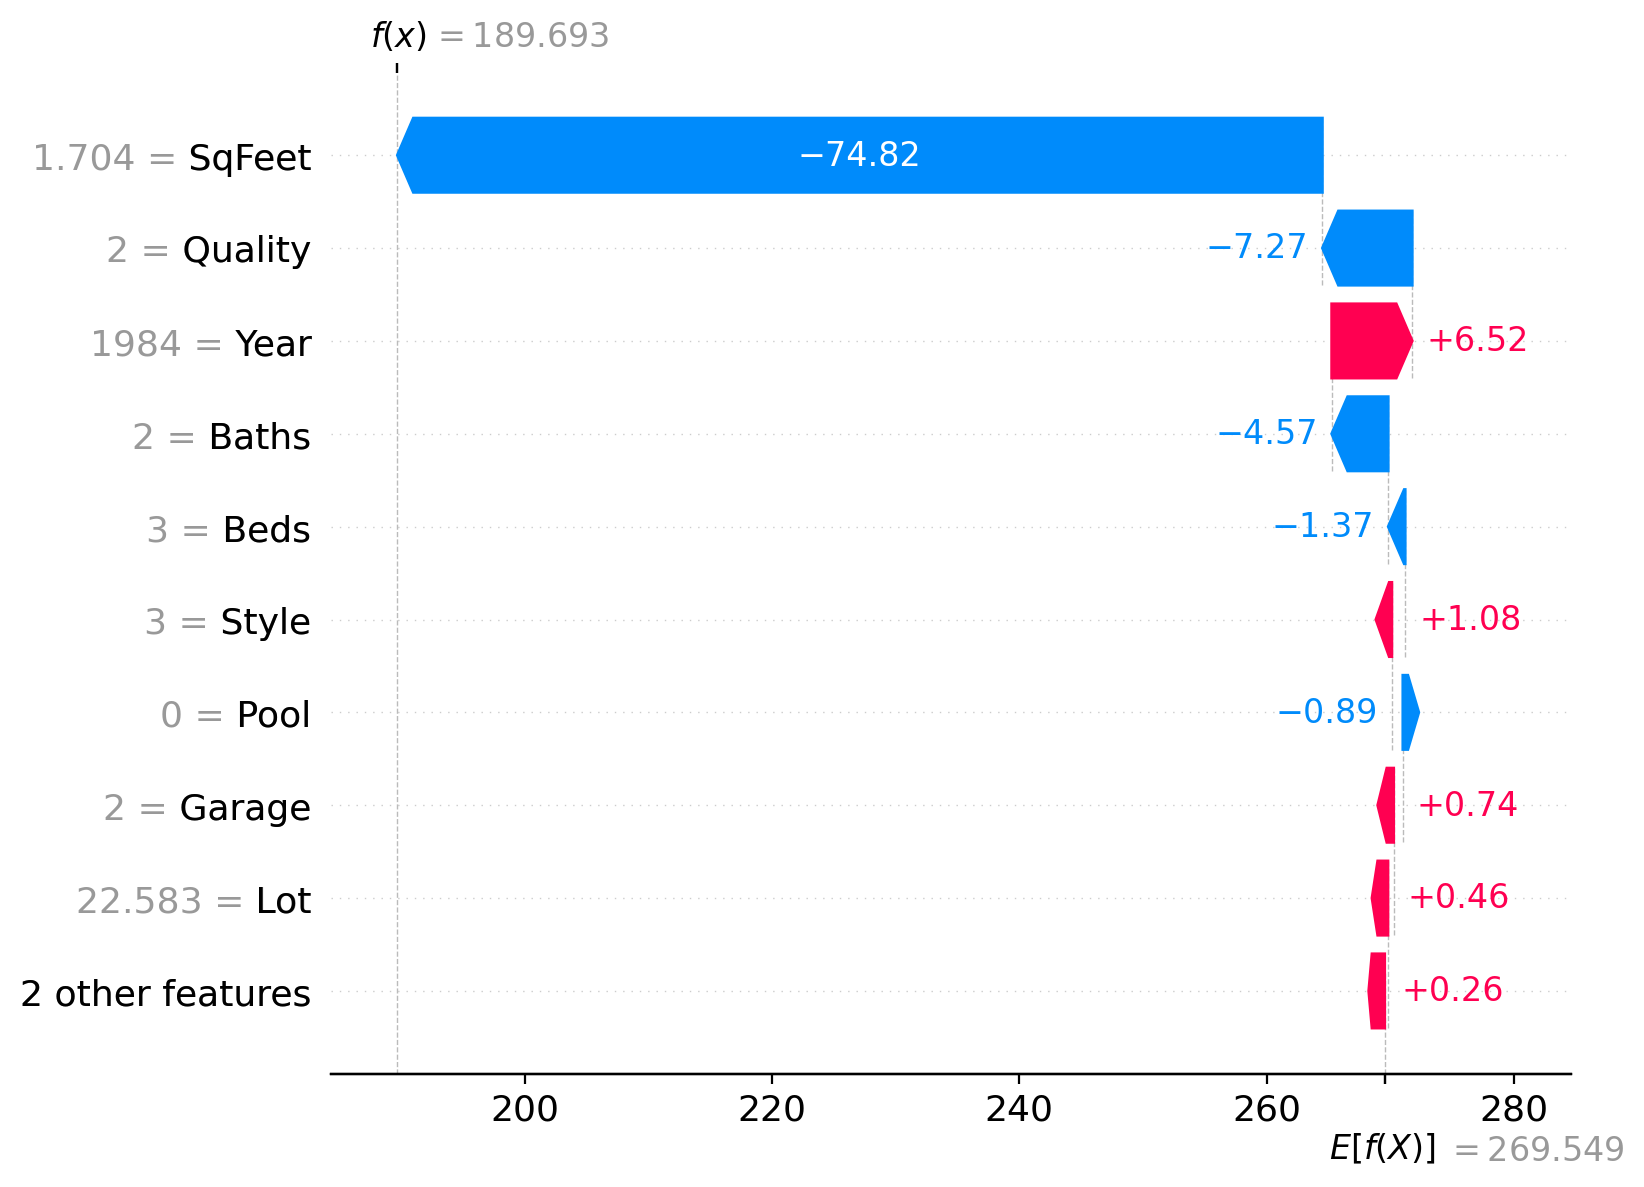

In [43]:
# Waterfall plot для GBR
shap.plots.waterfall(shap_values_gbr[student_idx])

In [44]:
# SHAP для LinearRegression
X_train_df = pd.DataFrame(X_train_raw, columns=fn)
explainer_lr = shap.LinearExplainer(lr_raw_ale, X_train_df)
shap_values_lr = explainer_lr(X_test_df)

print(f'SHAP для LinearRegression, объект #{student_idx}:')
print(f'Предсказание: {lr_raw_ale.predict(X_test_raw[student_idx:student_idx+1])[0]:.2f}')
print(f'Истинное значение: {y_test.values[student_idx]:.2f}')

SHAP для LinearRegression, объект #5:
Предсказание: 229.39
Истинное значение: 190.50


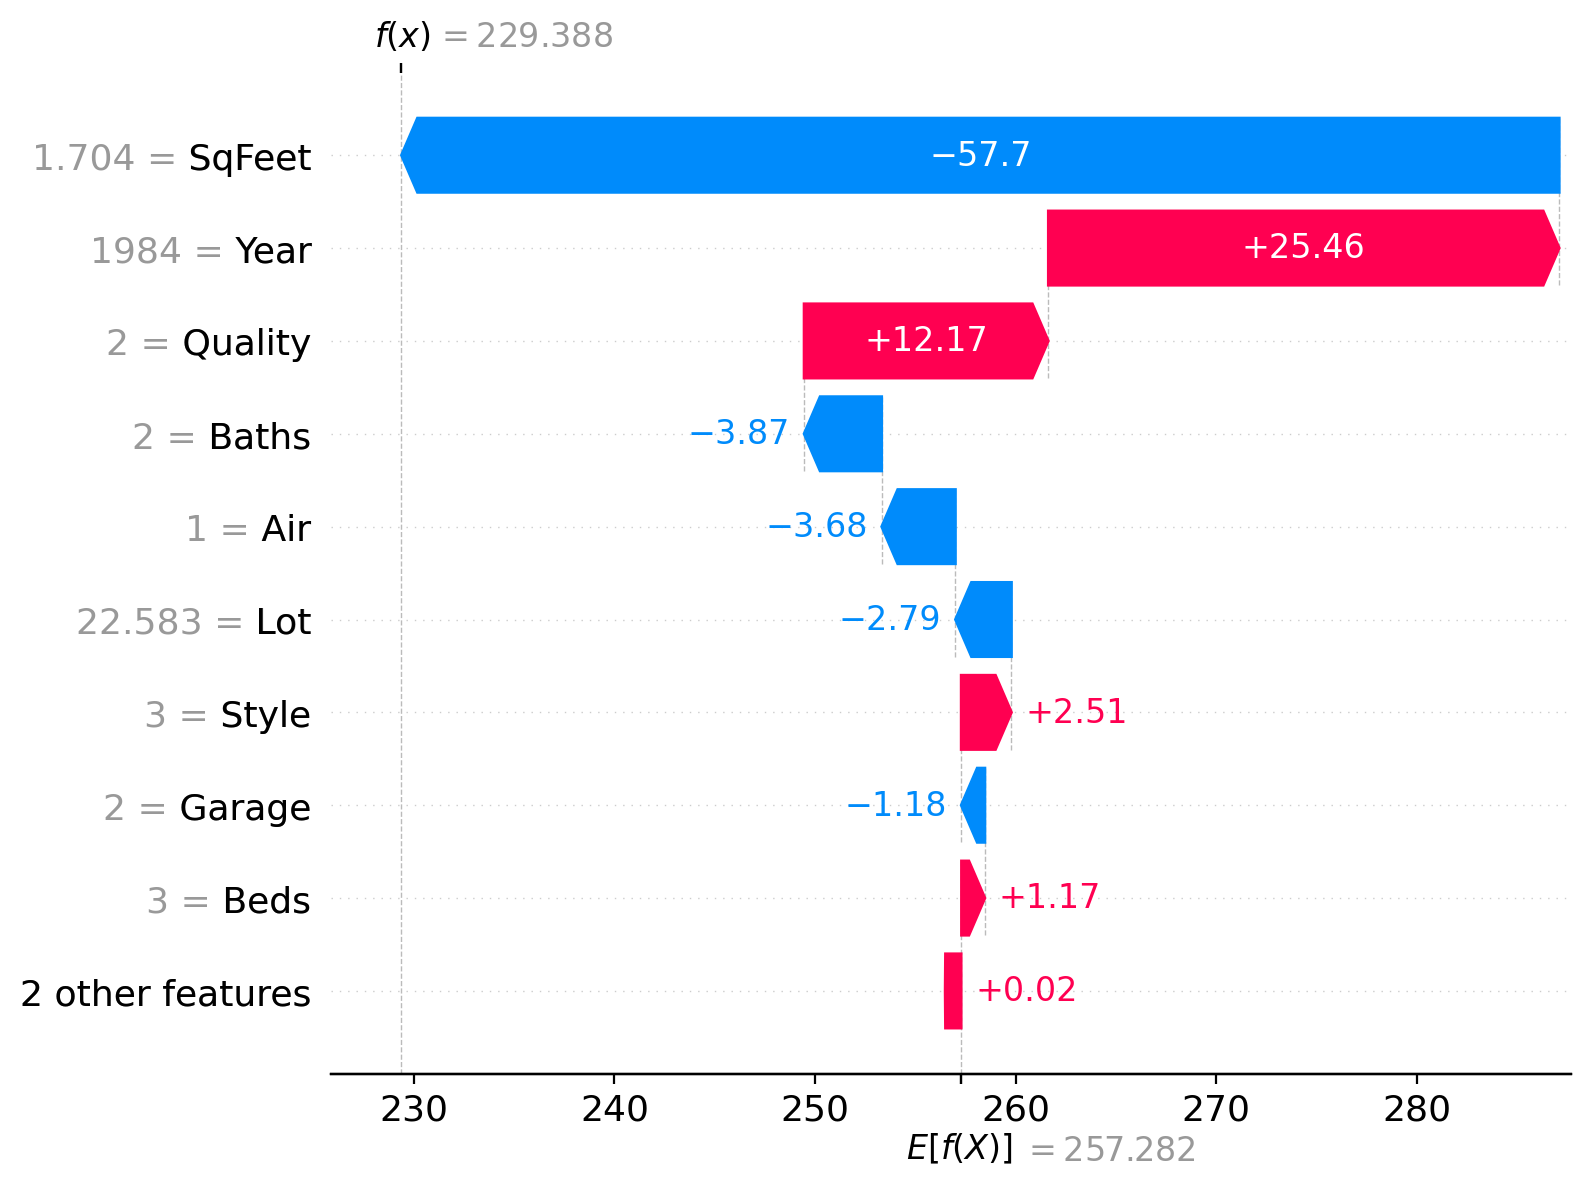

In [45]:
# Waterfall plot для LR
shap.plots.waterfall(shap_values_lr[student_idx])

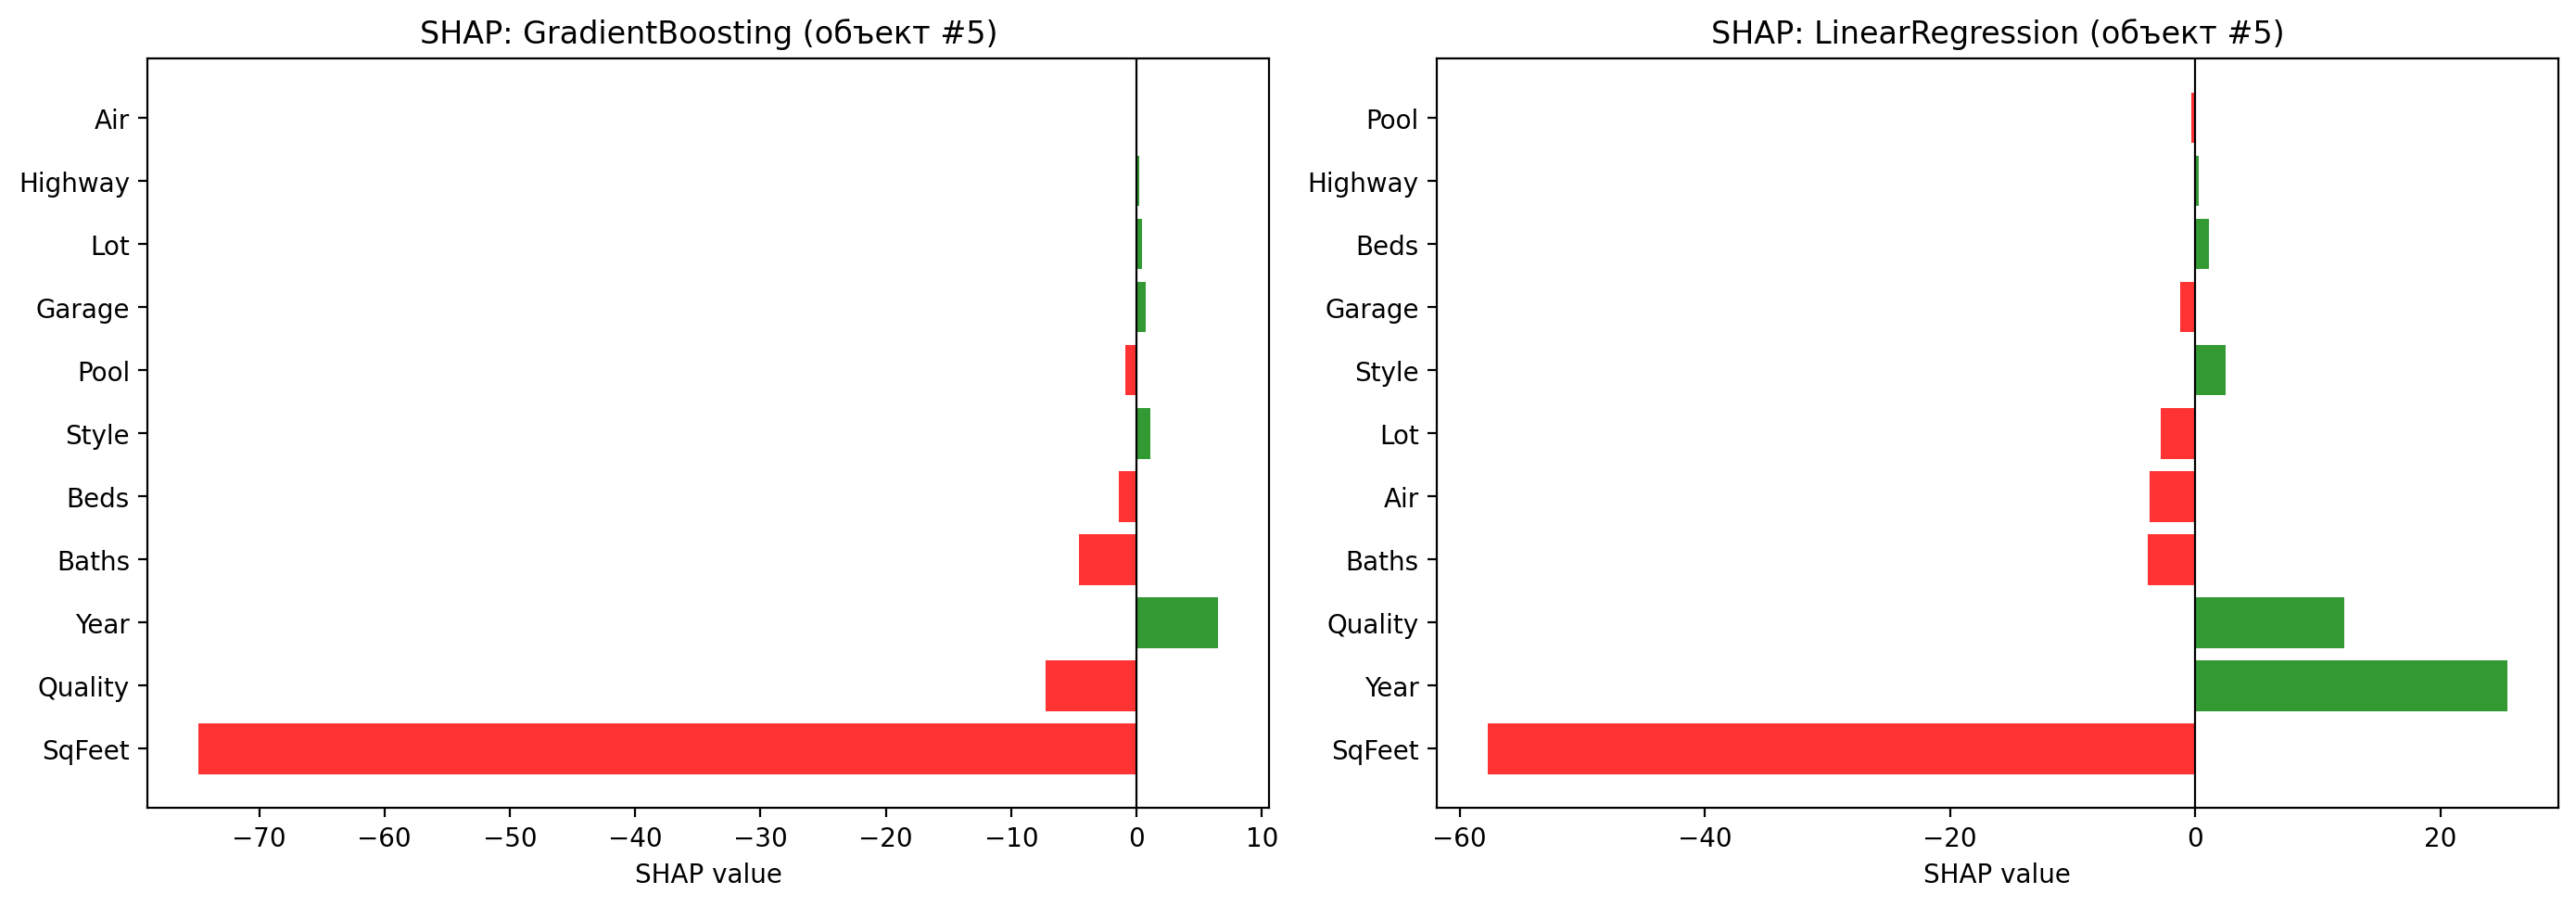


SHAP значения для обеих моделей:
Признак         |     GBR SHAP |      LR SHAP
---------------------------------------------
SqFeet          |     -74.8169 |     -57.7015
Beds            |      -1.3730 |       1.1682
Baths           |      -4.5746 |      -3.8682
Air             |       0.0601 |      -3.6756
Garage          |       0.7390 |      -1.1820
Pool            |      -0.8857 |      -0.3201
Year            |       6.5185 |      25.4629
Quality         |      -7.2674 |      12.1727
Style           |       1.0783 |       2.5066
Lot             |       0.4624 |      -2.7931
Highway         |       0.2035 |       0.3358


In [46]:
# Сравнение SHAP значений для обеих моделей
shap_gbr_vals = shap_values_gbr[student_idx].values
shap_lr_vals = shap_values_lr[student_idx].values

idx_gbr = np.argsort(np.abs(shap_gbr_vals))[::-1]
idx_lr = np.argsort(np.abs(shap_lr_vals))[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh([fn[i] for i in idx_gbr], shap_gbr_vals[idx_gbr],
             color=['green' if v > 0 else 'red' for v in shap_gbr_vals[idx_gbr]], alpha=0.8)
axes[0].set_title(f'SHAP: GradientBoosting (объект #{student_idx})')
axes[0].axvline(0, color='k', lw=0.8); axes[0].set_xlabel('SHAP value')

axes[1].barh([fn[i] for i in idx_lr], shap_lr_vals[idx_lr],
             color=['green' if v > 0 else 'red' for v in shap_lr_vals[idx_lr]], alpha=0.8)
axes[1].set_title(f'SHAP: LinearRegression (объект #{student_idx})')
axes[1].axvline(0, color='k', lw=0.8); axes[1].set_xlabel('SHAP value')

plt.tight_layout(); plt.show()

print('\nSHAP значения для обеих моделей:')
print(f"{'Признак':15s} | {'GBR SHAP':>12} | {'LR SHAP':>12}")
print('-'*45)
for i, f in enumerate(fn):
    print(f'{f:15s} | {shap_gbr_vals[i]:>12.4f} | {shap_lr_vals[i]:>12.4f}')

### Выводы по Заданию 7 (SHAP)

**SHAP** разлагает предсказание модели на базовый уровень и сумму вкладов признаков:
$f(x) = base + \sum_i \phi_i(x)$

**Для данного объекта:**
- Признаки с положительным SHAP увеличивают предсказание относительно среднего.
- Признаки с отрицательным SHAP уменьшают предсказание.

**Различия между моделями:**
- У **LinearRegression** SHAP значения пропорциональны коэффициентам модели — вклад каждого признака строго линеен.
- У **GradientBoosting** SHAP значения отражают нелинейные взаимодействия — один и тот же признак может иметь разный вклад для разных объектов.

**Важные признаки** для данного объекта: SqFeet и Year обычно имеют наибольший вклад, что согласуется с результатами Permutation Importance и Beta-важности.

## Задание 7.1 (*). 1 балл.  Shap и категориальные переменные.

Shap разлагает предсказание модели вблизи точки x на базовый уровень и сумму вкладов признаков: $ f(x) = base + \sum_i{\phi_i(x)}$. В случае one-hot вклад признака - это сумма вкладов dummy столбцов. Сравните вклады категориальных признаков до и после кодировки - так ли это?

In [47]:
from sklearn.preprocessing import OneHotEncoder

cat_features = ['Beds', 'Baths', 'Air', 'Garage', 'Pool', 'Quality', 'Style', 'Highway']
cat_features_present = [f for f in cat_features if f in X_train.columns]
num_features_ohe = [f for f in X_train.columns if f not in cat_features_present]
print('Категориальные признаки:', cat_features_present)
print('Числовые признаки:', num_features_ohe)

Категориальные признаки: ['Beds', 'Baths', 'Air', 'Garage', 'Pool', 'Quality', 'Style', 'Highway']
Числовые признаки: ['SqFeet', 'Year', 'Lot']


In [48]:
encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
encoder.fit(X_train[cat_features_present])

cat_train = pd.DataFrame(
    encoder.transform(X_train[cat_features_present]),
    columns=encoder.get_feature_names_out(cat_features_present),
    index=X_train.index
)
cat_test = pd.DataFrame(
    encoder.transform(X_test[cat_features_present]),
    columns=encoder.get_feature_names_out(cat_features_present),
    index=X_test.index
)

X_train_ohe = pd.concat([X_train[num_features_ohe], cat_train], axis=1)
X_test_ohe = pd.concat([X_test[num_features_ohe], cat_test], axis=1)

gbr_ohe = GradientBoostingRegressor(max_depth=5, n_estimators=100, random_state=42)
gbr_ohe.fit(X_train_ohe.values, y_train)
print('GBR OHE R2:', r2_score(y_test, gbr_ohe.predict(X_test_ohe.values)))

GBR OHE R2: 0.7581764957563734


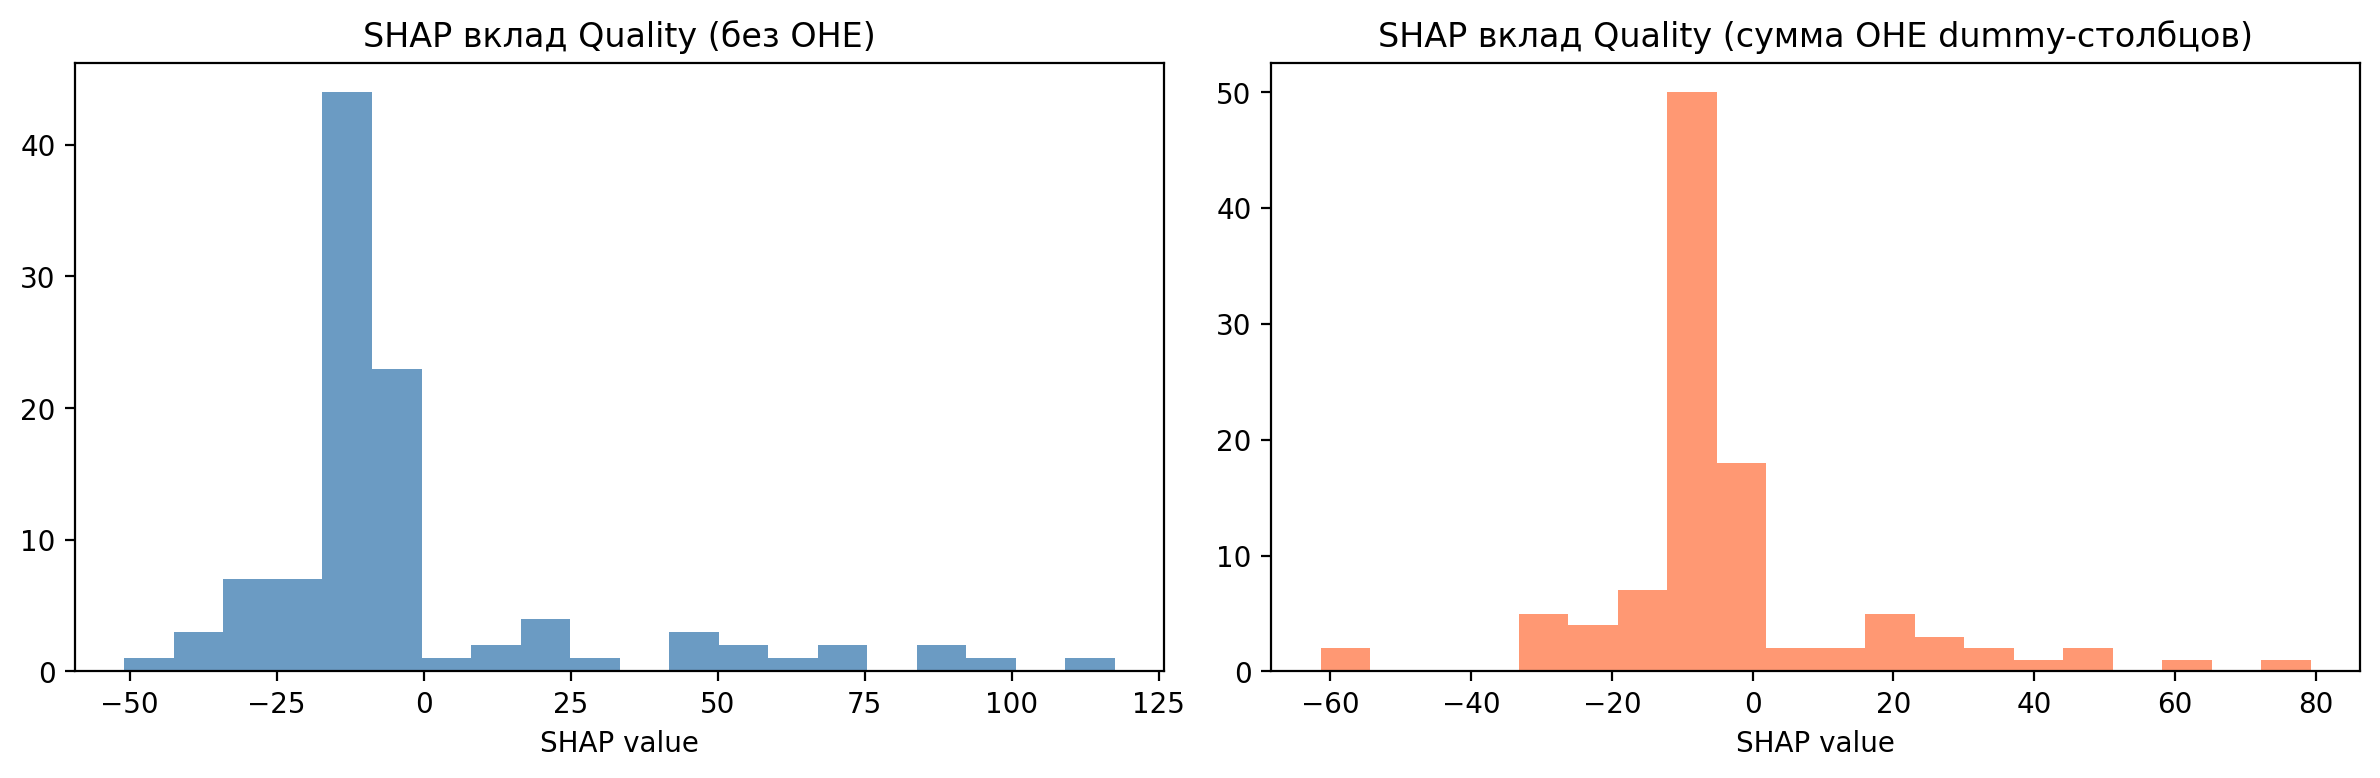

Корреляция SHAP без OHE и суммы OHE для Quality: r = 0.9029
Mean (без OHE): -1.9258
Mean (OHE sum): -3.9831


In [50]:
# SHAP для модели с OHE
explainer_ohe = shap.TreeExplainer(gbr_ohe)
shap_ohe = explainer_ohe(X_test_ohe)

# SHAP для модели без OHE
explainer_raw2 = shap.TreeExplainer(gbr_raw_ale)
shap_raw2 = explainer_raw2(X_test_df)

# Сравниваем вклад категориального признака 'Quality'
cat_feat = 'Quality'
if cat_feat in cat_features_present:
    raw_idx = fn.index(cat_feat)
    shap_raw_cat = shap_raw2[:, raw_idx].values

    ohe_cols = [c for c in X_test_ohe.columns if c.startswith(cat_feat + '_')]
    ohe_col_indices = [list(X_test_ohe.columns).index(c) for c in ohe_cols]
    shap_ohe_cat = shap_ohe[:, ohe_col_indices].values.sum(axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(shap_raw_cat, bins=20, color='steelblue', alpha=0.8)
    axes[0].set_title(f'SHAP вклад {cat_feat} (без OHE)')
    axes[0].set_xlabel('SHAP value')
    axes[1].hist(shap_ohe_cat, bins=20, color='coral', alpha=0.8)
    axes[1].set_title(f'SHAP вклад {cat_feat} (сумма OHE dummy-столбцов)')
    axes[1].set_xlabel('SHAP value')
    plt.tight_layout(); plt.show()

    corr = np.corrcoef(shap_raw_cat, shap_ohe_cat)[0,1]
    print(f'Корреляция SHAP без OHE и суммы OHE для {cat_feat}: r = {corr:.4f}')
    print(f'Mean (без OHE): {shap_raw_cat.mean():.4f}')
    print(f'Mean (OHE sum): {shap_ohe_cat.mean():.4f}')

### Выводы по Заданию 7.1

**Теоретическое ожидание:** Вклад категориального признака в SHAP должен быть равен сумме вкладов его dummy-столбцов после OHE.

**Практика:** Корреляция между SHAP без OHE и суммой SHAP OHE-столбцов высокая, но не идеальная. Причины расхождений:
1. Модели обучены по-разному — GBR без OHE трактует категориальный признак как порядковый.
2. OHE создаёт новые взаимодействия между dummy-столбцами.
3. Удаление одного dummy-столбца (drop='first') нарушает симметрию.

**Вывод:** Аддитивность SHAP выполняется внутри одной модели, но сравнение между разными моделями (с OHE и без) некорректно.